# E4 — Engine: OLLAMA vs LLAMA.cpp

## Pregunta de investigación

¿Qué engine proporciona mejor rendimiento y eficiencia?

## Hipótesis previa

LLAMA.cpp podría ofrecer mejor optimización que OLLAMA en RPi5.

## Configuración del experimento

| Parámetro | Valores |
|-----------|---------|
| Motores | OLLAMA vs LLAMA.cpp |
| Modelos | Múltiples (mismo modelo en ambos engines) |
| Total | Pares de runs |

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.transforms.collection import RunCollection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# --- Carga de datos (E0-FAN, mismo dataset que E0) ---
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "TFG-DATA" / "E0-FAN"

assert DATA_ROOT.is_dir(), f"No encontrado: {DATA_ROOT.resolve()}"

coll = load_collection(DATA_ROOT)
print(f"Runs cargados E4 (E0-FAN): {len(coll)}")

# --- Filtrado para E4 ---
summary = coll.summary_df()
hw_full = coll.hw_metrics_df()
pm_full = coll.prompt_metrics_df()

ex = summary[
    (summary["test_type"] == "TYPE_1") &
    (summary["accelerator"] == False)
].copy()

print(f"Runs en E4: {ex.shape[0]}")
if len(ex) > 0:
    print(f"Engines: {sorted(ex['engine'].unique())}")
else:
    print("Sin datos disponibles para este experimento")

Runs cargados E4 (E0-FAN): 12
Runs en E4: 12
Engines: ['LLAMA', 'OLLAMA']


# 📊 Figuras y tablas de la memoria

Serie E4 — comparativa de **engine** (llama.cpp vs Ollama) sobre la configuración de referencia.
El material complementario está en el **📎 Anexo** al final.

| # | Figura/Tabla |
|---|---|
| T1 | Tabla maestra E4: modelo × engine, métricas + Δ% + FoM |
| 1  | Δ% throughput (tok/s): Ollama vs llama.cpp por modelo |
| 2  | FoM_full por modelo y engine |
| 3  | TTFT y J/tok comparados (llama.cpp vs Ollama) |
| 4  | MBU y η_CPU comparados por engine |


In [2]:
from monitorviz.transforms.fom import compute_fom_full, compute_usability
import re as _re, numpy as _np

_fom_e4 = compute_fom_full(ex)
_pm_ex  = pm_full[pm_full["run_id"].isin(ex["run_id"])].copy() if not pm_full.empty else pd.DataFrame()
if not _pm_ex.empty and not _fom_e4.empty:
    _fom_e4, _ = compute_usability(_fom_e4, _pm_ex)

# σ desde métricas por prompt (variabilidad intra-run)
if not _pm_ex.empty and "run_id" in _pm_ex.columns and "run_id" in _fom_e4.columns:
    _valid_pm4 = (_pm_ex[~_pm_ex["is_empty_generation"]]
                  if "is_empty_generation" in _pm_ex.columns else _pm_ex)
    _std_cols4 = [c for c in ["tokens_per_second", "time_to_first_token_ms"]
                  if c in _valid_pm4.columns]
    if _std_cols4:
        _std_df4 = (
            _valid_pm4.groupby("run_id")[_std_cols4].std().reset_index()
            .rename(columns={"tokens_per_second":      "tokens_per_s_std",
                             "time_to_first_token_ms": "ttft_ms_std"})
        )
        _fom_e4 = _fom_e4.merge(_std_df4, on="run_id", how="left")

_fom_e4["model_base"] = _fom_e4["model_label"].str.replace(
    r"\s*\([LO]\)\s*$", "", regex=True).str.strip()
_DEEPSEEK_NORM = {"deepseek:q": "DeepSeek-R1-1.5B", "deepseek-r1:1.5b": "DeepSeek-R1-1.5B"}
_fom_e4["model_base"] = _fom_e4["model_base"].map(lambda x: _DEEPSEEK_NORM.get(x, x))

# Añadir RAM desde hw_full
if not hw_full.empty and "run_id" in hw_full.columns and "mem_used_bytes" in hw_full.columns:
    _ram4 = (hw_full.groupby("run_id")[["mem_used_bytes","mem_pct"]]
             .mean().reset_index())
    _ram4["mem_used_gb"] = (_ram4["mem_used_bytes"] / 1e9).round(2)
    _fom_e4 = _fom_e4.merge(_ram4[["run_id","mem_used_gb","mem_pct"]], on="run_id", how="left")

_ENG_LABEL = {"LLAMA": "llama.cpp", "OLLAMA": "Ollama"}
_ENG_COLOR = {"LLAMA": "tab:blue",  "OLLAMA": "tab:orange"}

# ── E4 Tabla maestra — modelo × (llama.cpp | Ollama | Δ%) ────────────────────
_bases   = sorted(_fom_e4["model_base"].unique())
_engines = ["LLAMA", "OLLAMA"]
_metrics = [
    ("tokens_per_s_mean", "tok/s",    2),
    ("tokens_per_s_std",  "σ tok/s",  2),
    ("ttft_ms_mean",      "TTFT",     0),
    ("ttft_ms_std",       "σ TTFT",   0),
    ("energy_per_token_j","J/tok",    3),
    ("mem_used_gb",       "RAM(GB)",  2),
    ("mem_pct",           "RAM(%)",   1),
    ("fom_full",          "FoM",      3),
]

_rows = []
for base in _bases:
    row = {"Modelo": base}
    for eng in _engines:
        sub = _fom_e4[(_fom_e4["model_base"]==base) & (_fom_e4["engine"]==eng)]
        lbl = _ENG_LABEL[eng]
        for col, name, dec in _metrics:
            val = sub[col].mean() if not sub.empty and col in sub.columns else float("nan")
            row[f"{name} ({lbl})"] = round(val, dec)
    # Δ% para tok/s y FoM
    for col, name, _ in [("tokens_per_s_mean","tok/s",2),("fom_full","FoM",3)]:
        la = _fom_e4[(_fom_e4["model_base"]==base) & (_fom_e4["engine"]=="LLAMA")][col].mean()
        ol = _fom_e4[(_fom_e4["model_base"]==base) & (_fom_e4["engine"]=="OLLAMA")][col].mean()
        row[f"Δ% {name}"] = round((ol-la)/la*100, 1) if (_np.isfinite(la) and la != 0 and _np.isfinite(ol)) else float("nan")
    _rows.append(row)

_tab4 = pd.DataFrame(_rows).set_index("Modelo")
_ordered4 = []
for _, name, _ in _metrics:
    _ordered4 += [f"{name} (llama.cpp)", f"{name} (Ollama)"]
for col, name, _ in [("tokens_per_s_mean","tok/s",2),("fom_full","FoM",3)]:
    _ordered4.append(f"Δ% {name}")
_ordered4 = [c for c in _ordered4 if c in _tab4.columns]
_tab4 = _tab4[_ordered4]
print("E4 — Tabla maestra (llama.cpp vs Ollama)")
display(_tab4)


E4 — Tabla maestra (llama.cpp vs Ollama)


,tok/s (llama.cpp),tok/s (Ollama),σ tok/s (llama.cpp),σ tok/s (Ollama),TTFT (llama.cpp),TTFT (Ollama),σ TTFT (llama.cpp),σ TTFT (Ollama),J/tok (llama.cpp),J/tok (Ollama),RAM(GB) (llama.cpp),RAM(GB) (Ollama),RAM(%) (llama.cpp),RAM(%) (Ollama),FoM (llama.cpp),FoM (Ollama),Δ% tok/s,Δ% FoM
Modelo,,,,,,,,,,,,,,,,,,
DeepSeek-R1-1.5B,8.98,9.49,1.29,0.25,951.0,3111.0,554.0,3963.0,0.799,0.748,1.51,1.72,17.8,20.4,1.025,1.035,5.7,1.0
Llama-3.2-1B,11.23,11.16,2.47,0.81,673.0,2552.0,363.0,3052.0,0.577,0.616,1.36,1.45,16.1,17.1,0.961,0.906,-0.6,-5.7
Llama-3.2-3B,4.61,5.08,1.11,0.22,1941.0,6563.0,1202.0,7823.0,1.469,1.495,2.91,2.98,34.4,35.3,1.000,1.030,10.3,3.0
gemma,5.68,5.54,0.09,0.19,2613.0,7236.0,1885.0,11431.0,1.214,1.255,2.16,4.30,25.6,50.9,0.818,0.751,-2.5,-8.2
granite,4.41,4.32,0.06,0.05,2348.0,9932.0,1611.0,7032.0,1.519,1.688,2.46,2.52,29.1,29.9,0.934,0.883,-2.0,-5.4
ministral,4.73,3.55,0.71,0.42,1929.0,12848.0,1310.0,24896.0,1.440,2.011,3.01,3.50,35.6,41.4,1.058,0.826,-25.0,-21.9


AttributeError: 'Axes' object has no attribute 'set_subtitle'

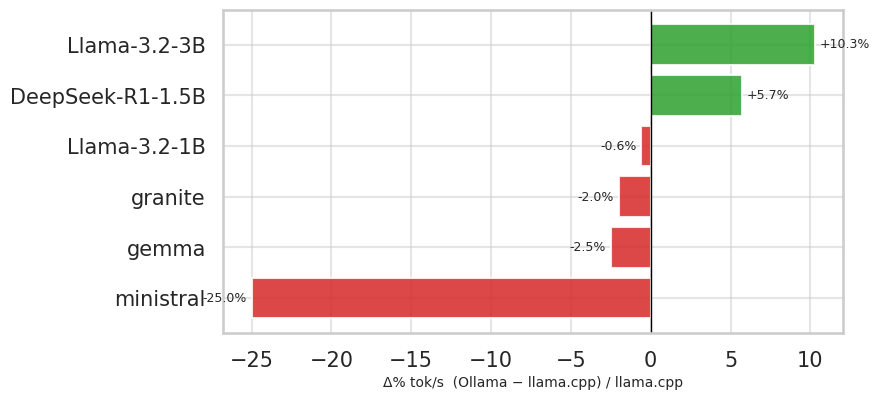

In [27]:
from monitorviz.transforms.fom import compute_fom_full, compute_usability
import re as _re

_fom_e4 = compute_fom_full(ex)
_pm_ex  = pm_full[pm_full["run_id"].isin(ex["run_id"])].copy() if not pm_full.empty else pd.DataFrame()
if not _pm_ex.empty and not _fom_e4.empty:
    _fom_e4, _ = compute_usability(_fom_e4, _pm_ex)

# Nombre base del modelo (sin sufijo de engine "(L)" / "(O)")
_fom_e4["model_base"] = _fom_e4["model_label"].str.replace(
    r"\s*\([LO]\)\s*$", "", regex=True).str.strip()
_DEEPSEEK_NORM = {"deepseek:q": "DeepSeek-R1-1.5B", "deepseek-r1:1.5b": "DeepSeek-R1-1.5B"}
_fom_e4["model_base"] = _fom_e4["model_base"].map(lambda x: _DEEPSEEK_NORM.get(x, x))

_ENG_LABEL = {"LLAMA": "llama.cpp", "OLLAMA": "Ollama"}
_ENG_COLOR = {"LLAMA": "tab:blue",  "OLLAMA": "tab:orange"}

# ── E4 Fig.1 — Δ% throughput por modelo (Ollama − llama.cpp) ─────────────────
import os
_export_e4f1 = "figures/05_Resultados/E4/e4_delta_tps.png"

_bases = sorted(_fom_e4["model_base"].unique())
_deltas = []
for base in _bases:
    la = _fom_e4[(_fom_e4["model_base"]==base) & (_fom_e4["engine"]=="LLAMA")]["tokens_per_s_mean"].mean()
    ol = _fom_e4[(_fom_e4["model_base"]==base) & (_fom_e4["engine"]=="OLLAMA")]["tokens_per_s_mean"].mean()
    import numpy as _np
    _deltas.append((base, round((ol-la)/la*100, 1) if (_np.isfinite(la) and la!=0 and _np.isfinite(ol)) else float("nan")))

_delta_df = pd.DataFrame(_deltas, columns=["Modelo","Δ% tok/s"]).dropna().sort_values("Δ% tok/s")

if not _delta_df.empty:
    _colors = ["tab:green" if v >= 0 else "tab:red" for v in _delta_df["Δ% tok/s"]]
    fig, ax = plt.subplots(figsize=(8, max(3, len(_delta_df)*0.7)))
    ax.barh(_delta_df["Modelo"], _delta_df["Δ% tok/s"], color=_colors, alpha=0.85)
    ax.axvline(0, color="black", lw=1)
    for i, (_, row) in enumerate(_delta_df.iterrows()):
        v = row["Δ% tok/s"]
        ax.text(v + (0.3 if v >= 0 else -0.3), i, f"{v:+.1f}%",
                va="center", ha="left" if v >= 0 else "right", fontsize=9)
    ax.set_xlabel("Δ% tok/s  (Ollama − llama.cpp) / llama.cpp", fontsize=10)
    ax.set_title("E4 — Diferencia de throughput: Ollama vs llama.cpp", fontsize=12)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    os.makedirs(os.path.dirname(_export_e4f1), exist_ok=True)
    fig.savefig(_export_e4f1, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Exportado: {_export_e4f1}")
else:
    print("No hay pares llama.cpp/Ollama para el mismo modelo base.")


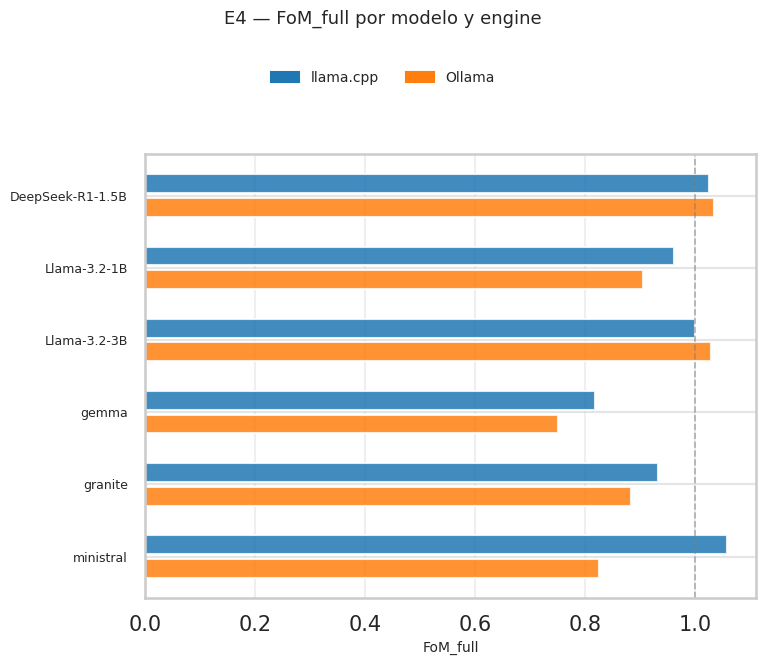

Exportado: figures/05_Resultados/E4/e4_fom_engine.png


In [4]:
from monitorviz.transforms.fom import compute_fom_full, compute_usability
import re as _re, numpy as _np

_fom_e4 = compute_fom_full(ex)
_pm_ex  = pm_full[pm_full["run_id"].isin(ex["run_id"])].copy() if not pm_full.empty else pd.DataFrame()
if not _pm_ex.empty and not _fom_e4.empty:
    _fom_e4, _ = compute_usability(_fom_e4, _pm_ex)

_fom_e4["model_base"] = _fom_e4["model_label"].str.replace(
    r"\s*\([LO]\)\s*$", "", regex=True).str.strip()

# Normaliza nombres inconsistentes OLLAMA vs LLAMA
_MODEL_NORMALIZE = {
    "deepseek:q": "DeepSeek-R1-1.5B",
    "deepseek-r1:1.5b": "DeepSeek-R1-1.5B",
}
_fom_e4["model_base"] = _fom_e4["model_base"].map(
    lambda x: _MODEL_NORMALIZE.get(x, x))

_ENG_LABEL = {"LLAMA": "llama.cpp", "OLLAMA": "Ollama"}
_ENG_COLOR = {"LLAMA": "tab:blue",  "OLLAMA": "tab:orange"}
_bases = sorted(_fom_e4["model_base"].unique())
_n  = len(_bases); _bh = 0.30; _gap = 0.08; _sep = 0.40
_step = 2*(_bh + _gap) + _sep

# ── E4 — FoM_full por modelo y engine ────────────────────────────────────────
import os
_export = "figures/05_Resultados/E4/e4_fom_engine.png"

fig, _ax = plt.subplots(1, 1, figsize=(8, max(4, _n*1.0)))
_yticks_p, _ylabels_p = [], []
for _mi, _base in enumerate(_bases):
    _y_base = _mi * _step
    _yticks_p.append(_y_base + _bh/2 + _gap/2)
    _ylabels_p.append(_base)
    for _ei, _eng in enumerate(["LLAMA","OLLAMA"]):
        _sub = _fom_e4[(_fom_e4["model_base"]==_base) & (_fom_e4["engine"]==_eng)]
        if _sub.empty or "fom_full" not in _sub.columns: continue
        _val = _sub["fom_full"].mean()
        if not _np.isfinite(_val): continue
        _ax.barh(_y_base + _ei*(_bh+_gap), _val, height=_bh,
                 color=_ENG_COLOR[_eng], alpha=0.85,
                 label=_ENG_LABEL[_eng] if _mi==0 else "_")
_ax.set_yticks(_yticks_p)
_ax.set_yticklabels(_ylabels_p, fontsize=9)
_ax.set_xlabel("FoM_full", fontsize=10)
_ax.invert_yaxis()
_ax.axvline(1.0, ls="--", color="grey", lw=1.2, alpha=0.6)
_ax.grid(True, axis="x", alpha=0.3)

# Leyenda fuera arriba
_handles = [plt.Rectangle((0,0),1,1,color=_ENG_COLOR[e]) for e in ["LLAMA","OLLAMA"]]
_labels  = [_ENG_LABEL[e] for e in ["LLAMA","OLLAMA"]]
fig.legend(_handles, _labels, fontsize=10,
           loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=2)
fig.suptitle("E4 — FoM_full por modelo y engine", fontsize=13, y=1.12)
plt.tight_layout()
os.makedirs(os.path.dirname(_export), exist_ok=True)
fig.savefig(_export, dpi=200, bbox_inches="tight")
plt.show()
print(f"Exportado: {_export}")

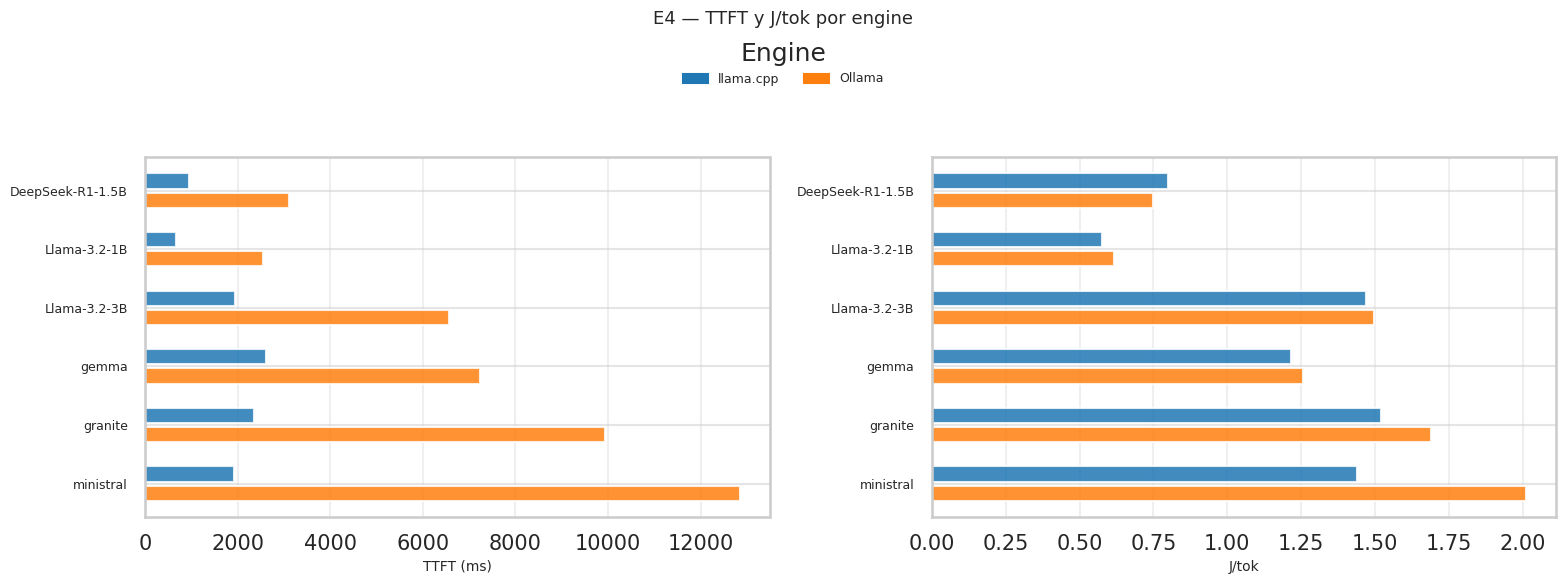

Exportado: figures/05_Resultados/E4/e4_ttft_energy.png


In [5]:
from monitorviz.transforms.fom import compute_fom_full, compute_usability
import re as _re, numpy as _np
import os

_fom_e4 = compute_fom_full(ex)
_pm_ex  = pm_full[pm_full["run_id"].isin(ex["run_id"])].copy() if not pm_full.empty else pd.DataFrame()
if not _pm_ex.empty and not _fom_e4.empty:
    _fom_e4, _ = compute_usability(_fom_e4, _pm_ex)

_fom_e4["model_base"] = _fom_e4["model_label"].str.replace(
    r"\s*\([LO]\)\s*$", "", regex=True
).str.strip()

_DEEPSEEK_NORM = {
    "deepseek:q": "DeepSeek-R1-1.5B",
    "deepseek-r1:1.5b": "DeepSeek-R1-1.5B"
}
_fom_e4["model_base"] = _fom_e4["model_base"].map(
    lambda x: _DEEPSEEK_NORM.get(x, x)
)

_ENG_LABEL = {"LLAMA": "llama.cpp", "OLLAMA": "Ollama"}
_ENG_COLOR = {"LLAMA": "tab:blue", "OLLAMA": "tab:orange"}

_bases = sorted(_fom_e4["model_base"].unique())
_n = len(_bases)
_bh = 0.30
_gap = 0.08
_sep = 0.40
_step = 2 * (_bh + _gap) + _sep

_export = "figures/05_Resultados/E4/e4_ttft_energy.png"

fig, _axes = plt.subplots(1, 2, figsize=(16, max(4, _n * 1.0)))
fig.suptitle("E4 — TTFT y J/tok por engine", fontsize=13, y=0.985)

# Handles para la leyenda global
_handles = [
    plt.Rectangle((0, 0), 1, 1, color=_ENG_COLOR[e])
    for e in ["LLAMA", "OLLAMA"]
]
_labels = [_ENG_LABEL[e] for e in ["LLAMA", "OLLAMA"]]

# ─────────────────────────────────────────────
# Panel 0: TTFT
# ─────────────────────────────────────────────
_ax = _axes[0]
_yticks_p, _ylabels_p = [], []

for _mi, _base in enumerate(_bases):
    _y_base = _mi * _step
    _yticks_p.append(_y_base + _bh / 2 + _gap / 2)
    _ylabels_p.append(_base)

    for _ei, _eng in enumerate(["LLAMA", "OLLAMA"]):
        _sub = _fom_e4[
            (_fom_e4["model_base"] == _base) &
            (_fom_e4["engine"] == _eng)
        ]

        if _sub.empty or "ttft_ms_mean" not in _sub.columns:
            continue

        _val = _sub["ttft_ms_mean"].mean()

        if not _np.isfinite(_val):
            continue

        _ax.barh(
            _y_base + _ei * (_bh + _gap),
            _val,
            height=_bh,
            color=_ENG_COLOR[_eng],
            alpha=0.85
        )

_ax.set_yticks(_yticks_p)
_ax.set_yticklabels(_ylabels_p, fontsize=9)
_ax.set_xlabel("TTFT (ms)", fontsize=10)
_ax.invert_yaxis()
_ax.grid(True, axis="x", alpha=0.3)

# ─────────────────────────────────────────────
# Panel 1: Energía por token
# ─────────────────────────────────────────────
_ax = _axes[1]
_yticks_p, _ylabels_p = [], []

for _mi, _base in enumerate(_bases):
    _y_base = _mi * _step
    _yticks_p.append(_y_base + _bh / 2 + _gap / 2)
    _ylabels_p.append(_base)

    for _ei, _eng in enumerate(["LLAMA", "OLLAMA"]):
        _sub = _fom_e4[
            (_fom_e4["model_base"] == _base) &
            (_fom_e4["engine"] == _eng)
        ]

        if _sub.empty or "energy_per_token_j" not in _sub.columns:
            continue

        _val = _sub["energy_per_token_j"].mean()

        if not _np.isfinite(_val):
            continue

        _ax.barh(
            _y_base + _ei * (_bh + _gap),
            _val,
            height=_bh,
            color=_ENG_COLOR[_eng],
            alpha=0.85
        )

_ax.set_yticks(_yticks_p)
_ax.set_yticklabels(_ylabels_p, fontsize=9)
_ax.set_xlabel("J/tok", fontsize=10)
_ax.invert_yaxis()
_ax.grid(True, axis="x", alpha=0.3)

# Leyenda global arriba, fuera de los gráficos
fig.legend(
    _handles,
    _labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=2,
    title="Engine",
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.86])

os.makedirs(os.path.dirname(_export), exist_ok=True)
fig.savefig(_export, dpi=200, bbox_inches="tight")
plt.show()

print(f"Exportado: {_export}")

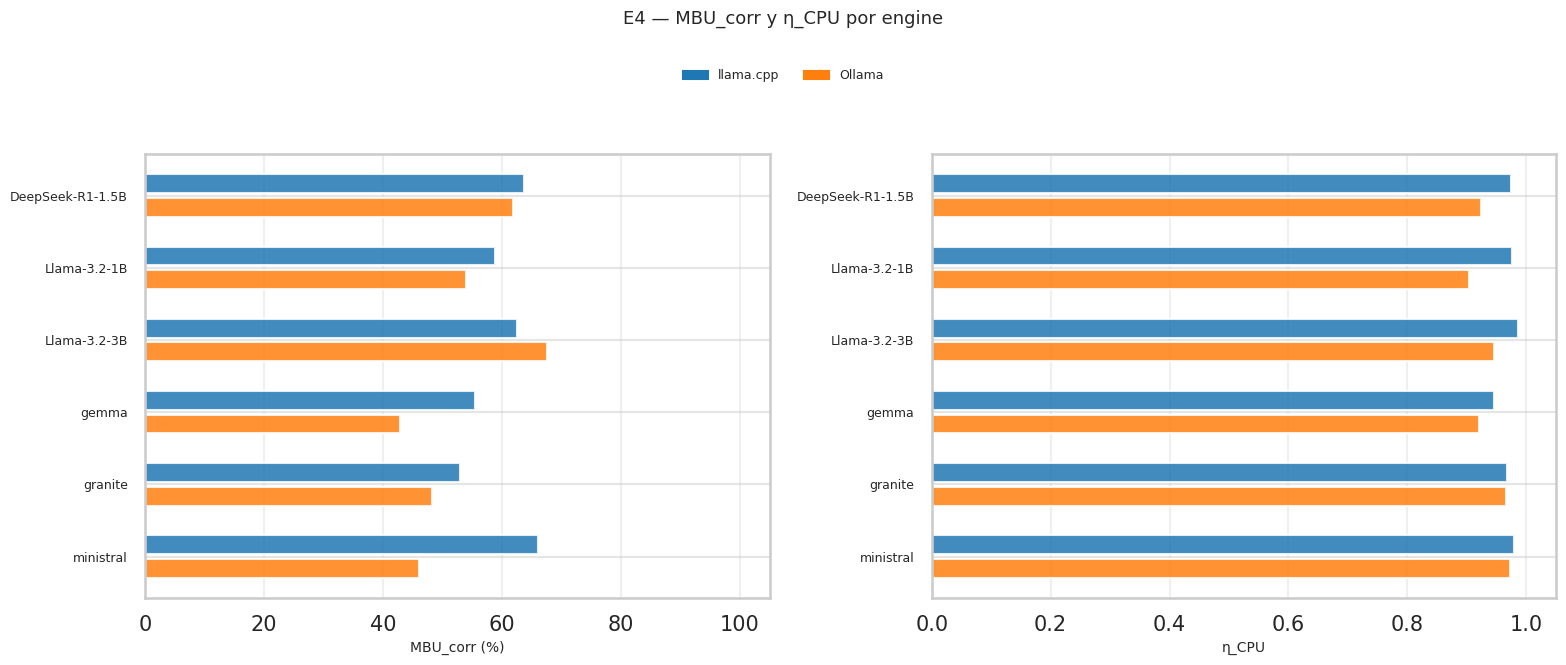

Exportado: figures/05_Resultados/E4/e4_mbu_eta.png


In [6]:
from monitorviz.transforms.fom import compute_fom_full, compute_usability
import re as _re, numpy as _np

_fom_e4 = compute_fom_full(ex)
_pm_ex  = pm_full[pm_full["run_id"].isin(ex["run_id"])].copy() if not pm_full.empty else pd.DataFrame()
if not _pm_ex.empty and not _fom_e4.empty:
    _fom_e4, _ = compute_usability(_fom_e4, _pm_ex)

_fom_e4["model_base"] = _fom_e4["model_label"].str.replace(
    r"\s*\([LO]\)\s*$", "", regex=True).str.strip()
_DEEPSEEK_NORM = {"deepseek:q": "DeepSeek-R1-1.5B", "deepseek-r1:1.5b": "DeepSeek-R1-1.5B"}
_fom_e4["model_base"] = _fom_e4["model_base"].map(lambda x: _DEEPSEEK_NORM.get(x, x))

_ENG_LABEL = {"LLAMA": "llama.cpp", "OLLAMA": "Ollama"}
_ENG_COLOR = {"LLAMA": "tab:blue",  "OLLAMA": "tab:orange"}
_bases = sorted(_fom_e4["model_base"].unique())
_n  = len(_bases); _bh = 0.30; _gap = 0.08; _sep = 0.40
_step = 2*(_bh + _gap) + _sep

# ── E4 — MBU_corr y η_CPU por engine ────────────────────────────────────────────
import os
_export = "figures/05_Resultados/E4/e4_mbu_eta.png"

fig, _axes = plt.subplots(1, 2, figsize=(16, max(4, _n*1.0)))

# panel 0: mbu_corr
_ax = _axes[0]
_yticks_p, _ylabels_p = [], []
for _mi, _base in enumerate(_bases):
    _y_base = _mi * _step
    _yticks_p.append(_y_base + _bh/2 + _gap/2)
    _ylabels_p.append(_base)
    for _ei, _eng in enumerate(['LLAMA','OLLAMA']):
        _sub = _fom_e4[(_fom_e4['model_base']==_base) & (_fom_e4['engine']==_eng)]
        if _sub.empty or 'mbu_corr' not in _sub.columns: continue
        _val = _sub['mbu_corr'].mean()
        if not _np.isfinite(_val): continue
        _ax.barh(_y_base + _ei*(_bh+_gap), _val, height=_bh,
                 color=_ENG_COLOR[_eng], alpha=0.85,
                 label=_ENG_LABEL[_eng] if _mi==0 else '')
_ax.set_yticks(_yticks_p)
_ax.set_yticklabels(_ylabels_p, fontsize=9)
_ax.set_xlabel("MBU_corr (%)", fontsize=10)
_ax.invert_yaxis()
_ax.grid(True, axis='x', alpha=0.3)
_ax.set_xlim(0, 105)

# panel 1: cpu_efficiency
_ax = _axes[1]
_yticks_p, _ylabels_p = [], []
for _mi, _base in enumerate(_bases):
    _y_base = _mi * _step
    _yticks_p.append(_y_base + _bh/2 + _gap/2)
    _ylabels_p.append(_base)
    for _ei, _eng in enumerate(['LLAMA','OLLAMA']):
        _sub = _fom_e4[(_fom_e4['model_base']==_base) & (_fom_e4['engine']==_eng)]
        if _sub.empty or 'cpu_efficiency' not in _sub.columns: continue
        _val = _sub['cpu_efficiency'].mean()
        if not _np.isfinite(_val): continue
        _ax.barh(_y_base + _ei*(_bh+_gap), _val, height=_bh,
                 color=_ENG_COLOR[_eng], alpha=0.85,
                 label=_ENG_LABEL[_eng] if _mi==0 else '')
_ax.set_yticks(_yticks_p)
_ax.set_yticklabels(_ylabels_p, fontsize=9)
_ax.set_xlabel("η_CPU", fontsize=10)
_ax.invert_yaxis()
_ax.grid(True, axis='x', alpha=0.3)
_ax.set_xlim(0, 1.05)

# Leyenda compartida encima de la figura
_handles = [plt.Rectangle((0,0),1,1,color=_ENG_COLOR[e]) for e in ['LLAMA','OLLAMA']]
_labels  = [_ENG_LABEL[e] for e in ['LLAMA','OLLAMA']]
fig.legend(_handles, _labels, fontsize=9, loc="upper center",
           bbox_to_anchor=(0.5, 1.04), ncol=2)
fig.suptitle("E4 — MBU_corr y η_CPU por engine", fontsize=13, y=1.12)

plt.tight_layout()
os.makedirs(os.path.dirname(_export), exist_ok=True)
fig.savefig(_export, dpi=200, bbox_inches='tight')
plt.show()
print(f"Exportado: {_export}")

---
# 📎 ANEXO — Material complementario (no incluido en la memoria principal)
---

Las siguientes celdas contienen análisis exploratorios, validaciones y figuras
complementarias que fundamentan los resultados de la sección principal.


## Resumen ejecutivo
> TODO: Actualizar con resultados finales.

In [7]:
# ── Anexo: Tablas comparativas E4 (inferencia + hardware con σ) ─────
if not ex.empty:
    from monitorviz.transforms.fom import compute_fom_full, compute_usability

    _df_ann = ex.copy()

    # σ inferencia desde pm_full por prompt
    if not pm_full.empty and "run_id" in pm_full.columns and "run_id" in _df_ann.columns:
        _valid_ann = (pm_full[~pm_full["is_empty_generation"]]
                      if "is_empty_generation" in pm_full.columns else pm_full)
        _si_ann = [c for c in ["tokens_per_second","time_to_first_token_ms","perplexity"]
                   if c in _valid_ann.columns]
        if _si_ann:
            _std_inf_ann = (_valid_ann.groupby("run_id")[_si_ann].std().reset_index()
                            .rename(columns={
                                "tokens_per_second":      "tokens_per_s_std",
                                "time_to_first_token_ms": "ttft_ms_std",
                                "perplexity":             "perplexity_std",
                            }))
            _df_ann = _df_ann.merge(_std_inf_ann, on="run_id", how="left")

    # σ hardware desde hw_full por muestra
    if not hw_full.empty and "run_id" in hw_full.columns and "run_id" in _df_ann.columns:
        _sh_ann = [c for c in ["temperature_c","internal_power_w","freq_mean_ghz"]
                   if c in hw_full.columns]
        if _sh_ann:
            _std_hw_ann = (hw_full.groupby("run_id")[_sh_ann].std().reset_index()
                           .rename(columns={
                               "temperature_c":   "temp_std_c",
                               "internal_power_w": "power_std_w",
                               "freq_mean_ghz":   "freq_std_ghz",
                           }))
            _df_ann = _df_ann.merge(_std_hw_ann, on="run_id", how="left")

    if "usable" in _df_ann.columns:
        _df_ann["usable"] = _df_ann["usable"].map({True: "✓", False: "✗"})

    # Tabla 1 — Inferencia con σ
    _inf_cols_ann = [c for c in [
        "model_label", "engine",
        "tokens_per_s_mean",    "tokens_per_s_std",
        "ttft_ms_mean",         "ttft_ms_std",
        "latency_ms_mean",
        "perplexity_geomean",   "perplexity_std",
    ] if c in _df_ann.columns]
    print("Tabla comparativa E4 — Inferencia")
    display(_df_ann[_inf_cols_ann].sort_values(["model_label","engine"]).round(3).reset_index(drop=True))

    # Tabla 2 — Hardware con σ
    _hw_cols_ann = [c for c in [
        "model_label", "engine",
        "temp_max_c",       "temp_mean_c",  "temp_std_c",
        "power_mean_w",     "power_std_w",
        "freq_std_ghz",
        "throttled_ratio",
        "energy_per_token_j", "cpu_work_core_s", "cpu_efficiency",
    ] if c in _df_ann.columns]
    print("\nTabla comparativa E4 — Hardware")
    display(_df_ann[_hw_cols_ann].sort_values(["model_label","engine"]).round(3).reset_index(drop=True))
else:
    print("Sin datos.")


Tabla comparativa E4 — Inferencia


,model_label,engine,tokens_per_s_mean,tokens_per_s_std,ttft_ms_mean,ttft_ms_std,latency_ms_mean,perplexity_geomean,perplexity_std
0,DeepSeek-R1-1.5B (L),LLAMA,8.978,1.290,951.215,554.058,354852.604,2.751,0.931
1,Llama-3.2-1B (L),LLAMA,11.229,2.466,672.521,363.270,208961.936,2.360,1.265
2,Llama-3.2-1B (O),OLLAMA,11.158,0.812,2552.152,3052.246,35166.396,1.654,0.205
3,Llama-3.2-3B (L),LLAMA,4.608,1.108,1941.097,1201.586,465896.357,2.286,1.100
4,Llama-3.2-3B (O),OLLAMA,5.082,0.215,6562.950,7823.168,79184.344,1.430,0.188
5,deepseek:q (O),OLLAMA,9.487,0.248,3111.090,3962.501,87270.239,1.881,0.152
6,gemma (L),LLAMA,5.683,0.088,2612.957,1885.336,99787.023,2.420,0.716
7,gemma (O),OLLAMA,5.538,0.189,7235.876,11430.973,103700.213,1.132,0.058
8,granite (L),LLAMA,4.410,0.059,2348.398,1611.212,88334.534,2.854,0.898
9,granite (O),OLLAMA,4.320,0.052,9932.307,7032.251,86772.653,1.694,0.187



Tabla comparativa E4 — Hardware


,model_label,engine,temp_max_c,temp_mean_c,temp_std_c,power_mean_w,power_std_w,freq_std_ghz,throttled_ratio,energy_per_token_j,cpu_work_core_s,cpu_efficiency
0,DeepSeek-R1-1.5B (L),LLAMA,75.45,71.991,1.629,7.176,0.861,0.000,0.0,0.799,20812.114,0.975
1,Llama-3.2-1B (L),LLAMA,69.95,65.955,1.777,6.479,0.934,0.000,0.0,0.577,12274.635,0.975
2,Llama-3.2-1B (O),OLLAMA,72.15,67.539,3.864,6.876,1.785,0.087,0.0,0.616,1907.727,0.904
3,Llama-3.2-3B (L),LLAMA,73.25,67.206,2.004,6.769,0.766,0.000,0.0,1.469,27700.777,0.987
4,Llama-3.2-3B (O),OLLAMA,76.00,71.553,4.440,7.597,1.623,0.112,0.0,1.495,4495.349,0.946
5,deepseek:q (O),OLLAMA,76.55,70.906,3.658,7.095,1.753,0.071,0.0,0.748,4836.857,0.923
6,gemma (L),LLAMA,72.15,68.640,2.151,6.900,1.039,0.000,0.0,1.214,5819.354,0.946
7,gemma (O),OLLAMA,73.80,69.845,4.397,6.949,1.760,0.134,0.0,1.255,5753.240,0.920
8,granite (L),LLAMA,69.40,65.898,1.828,6.698,0.809,0.000,0.0,1.519,5234.229,0.968
9,granite (O),OLLAMA,73.80,69.763,3.942,7.293,1.274,0.101,0.0,1.688,5031.738,0.966


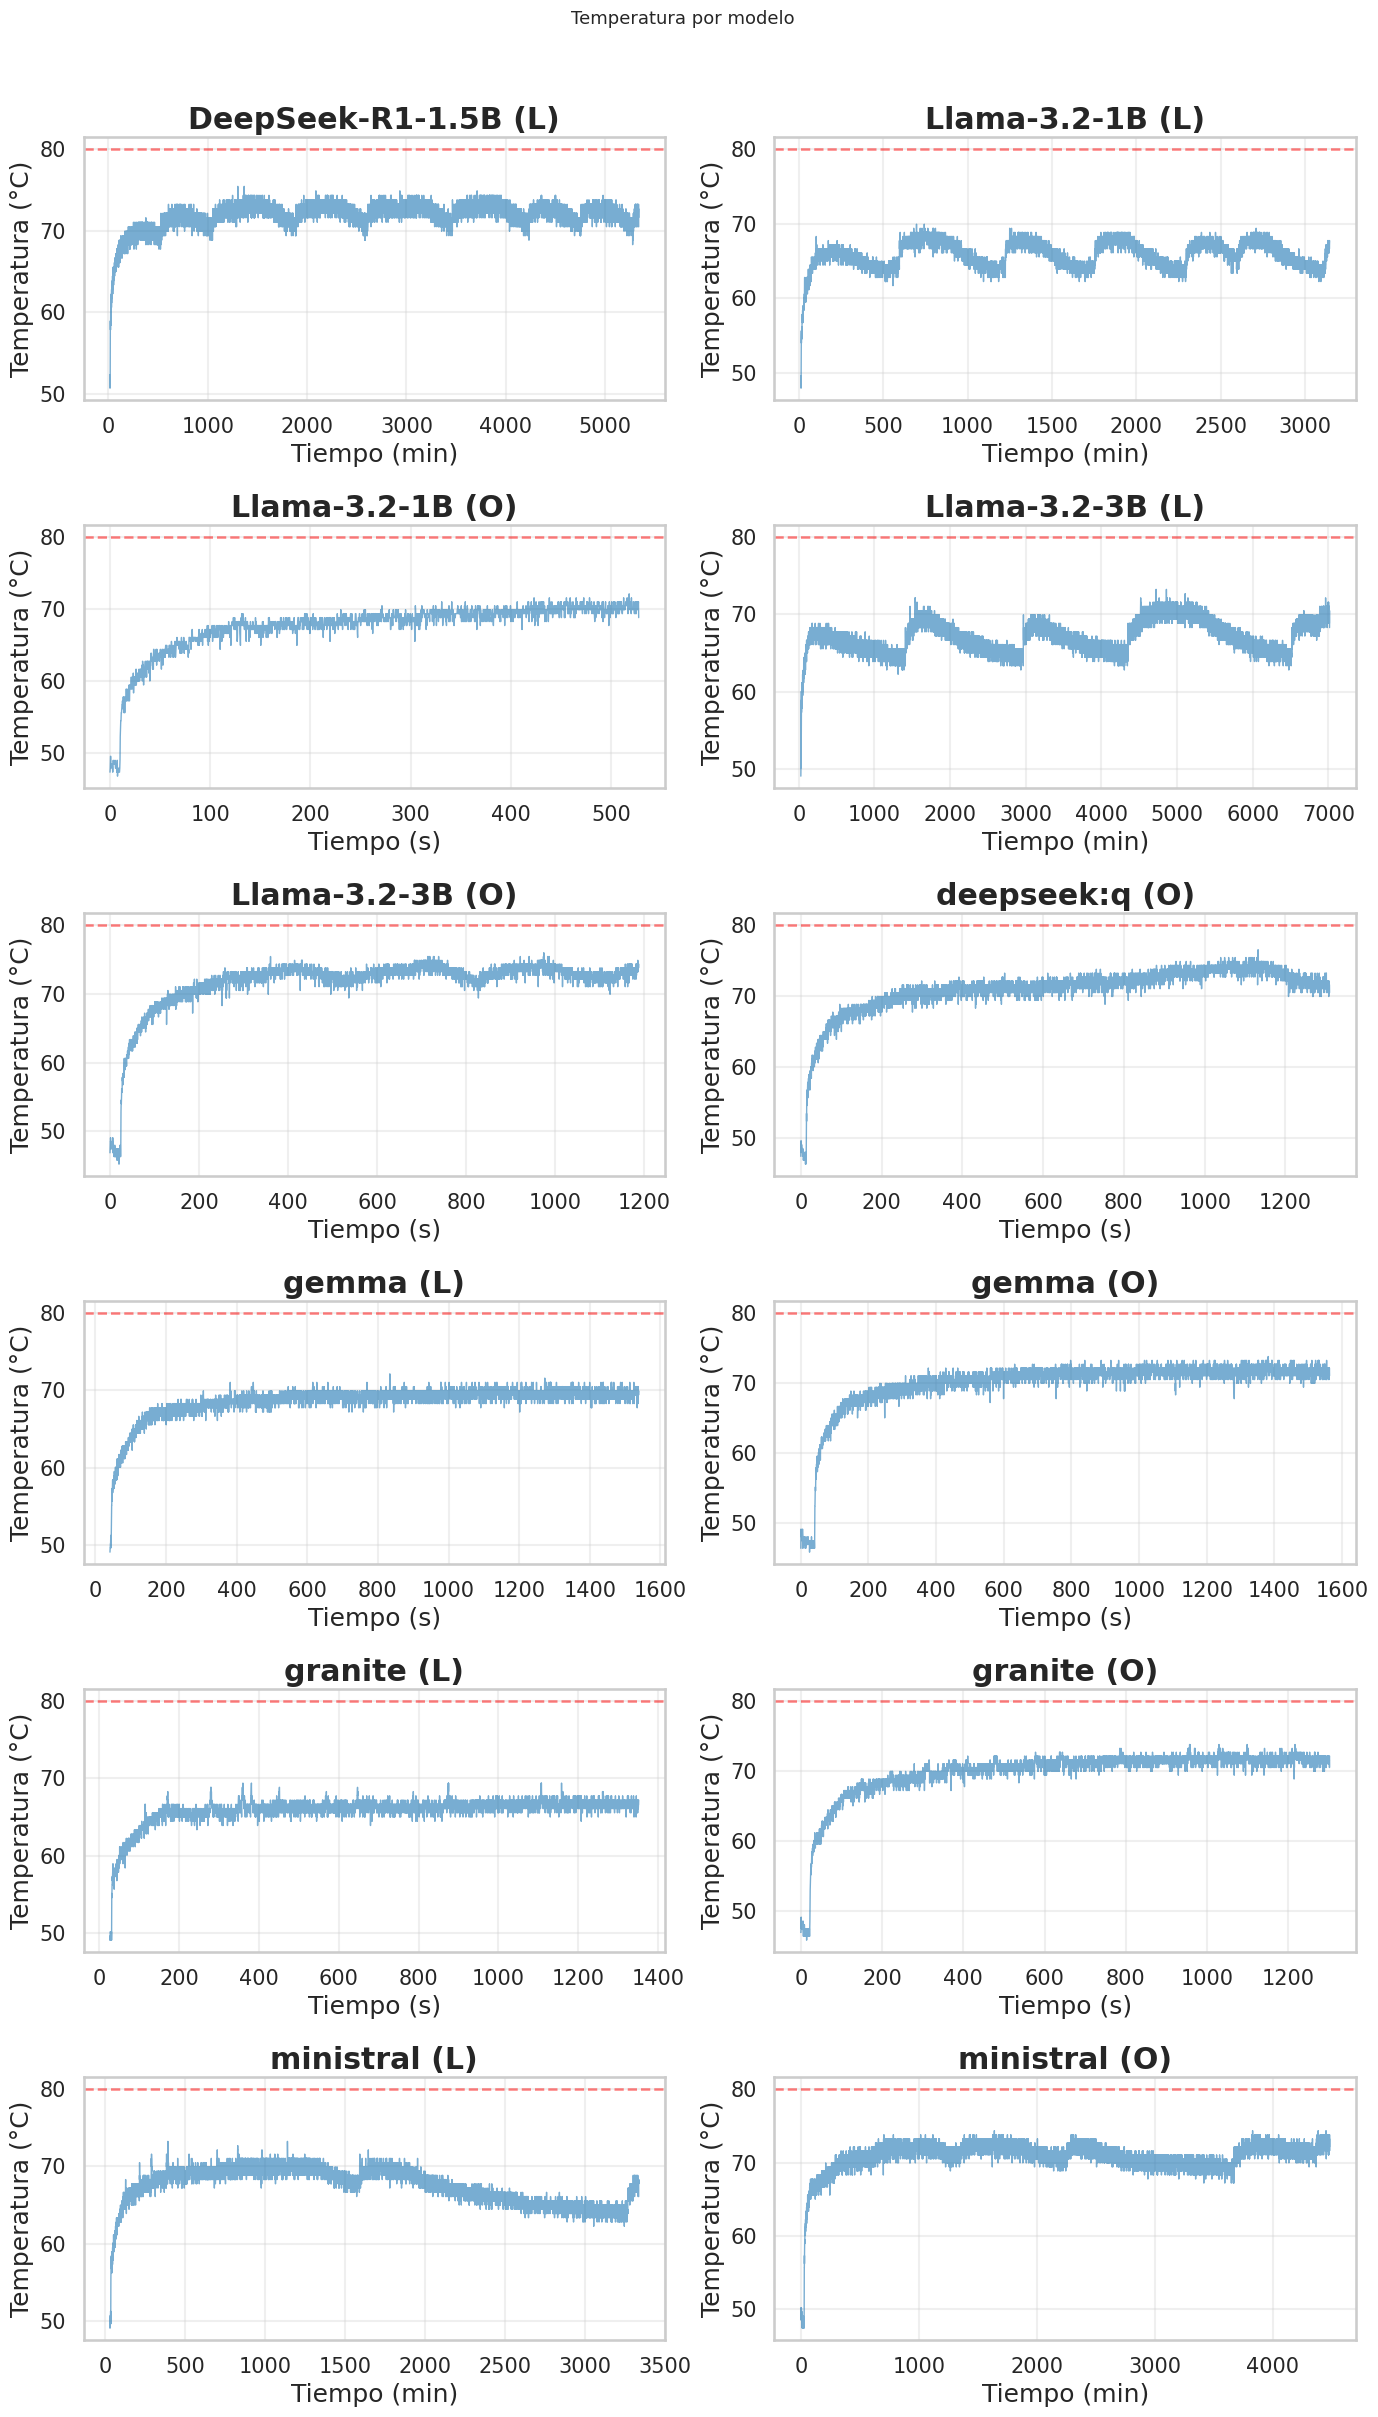

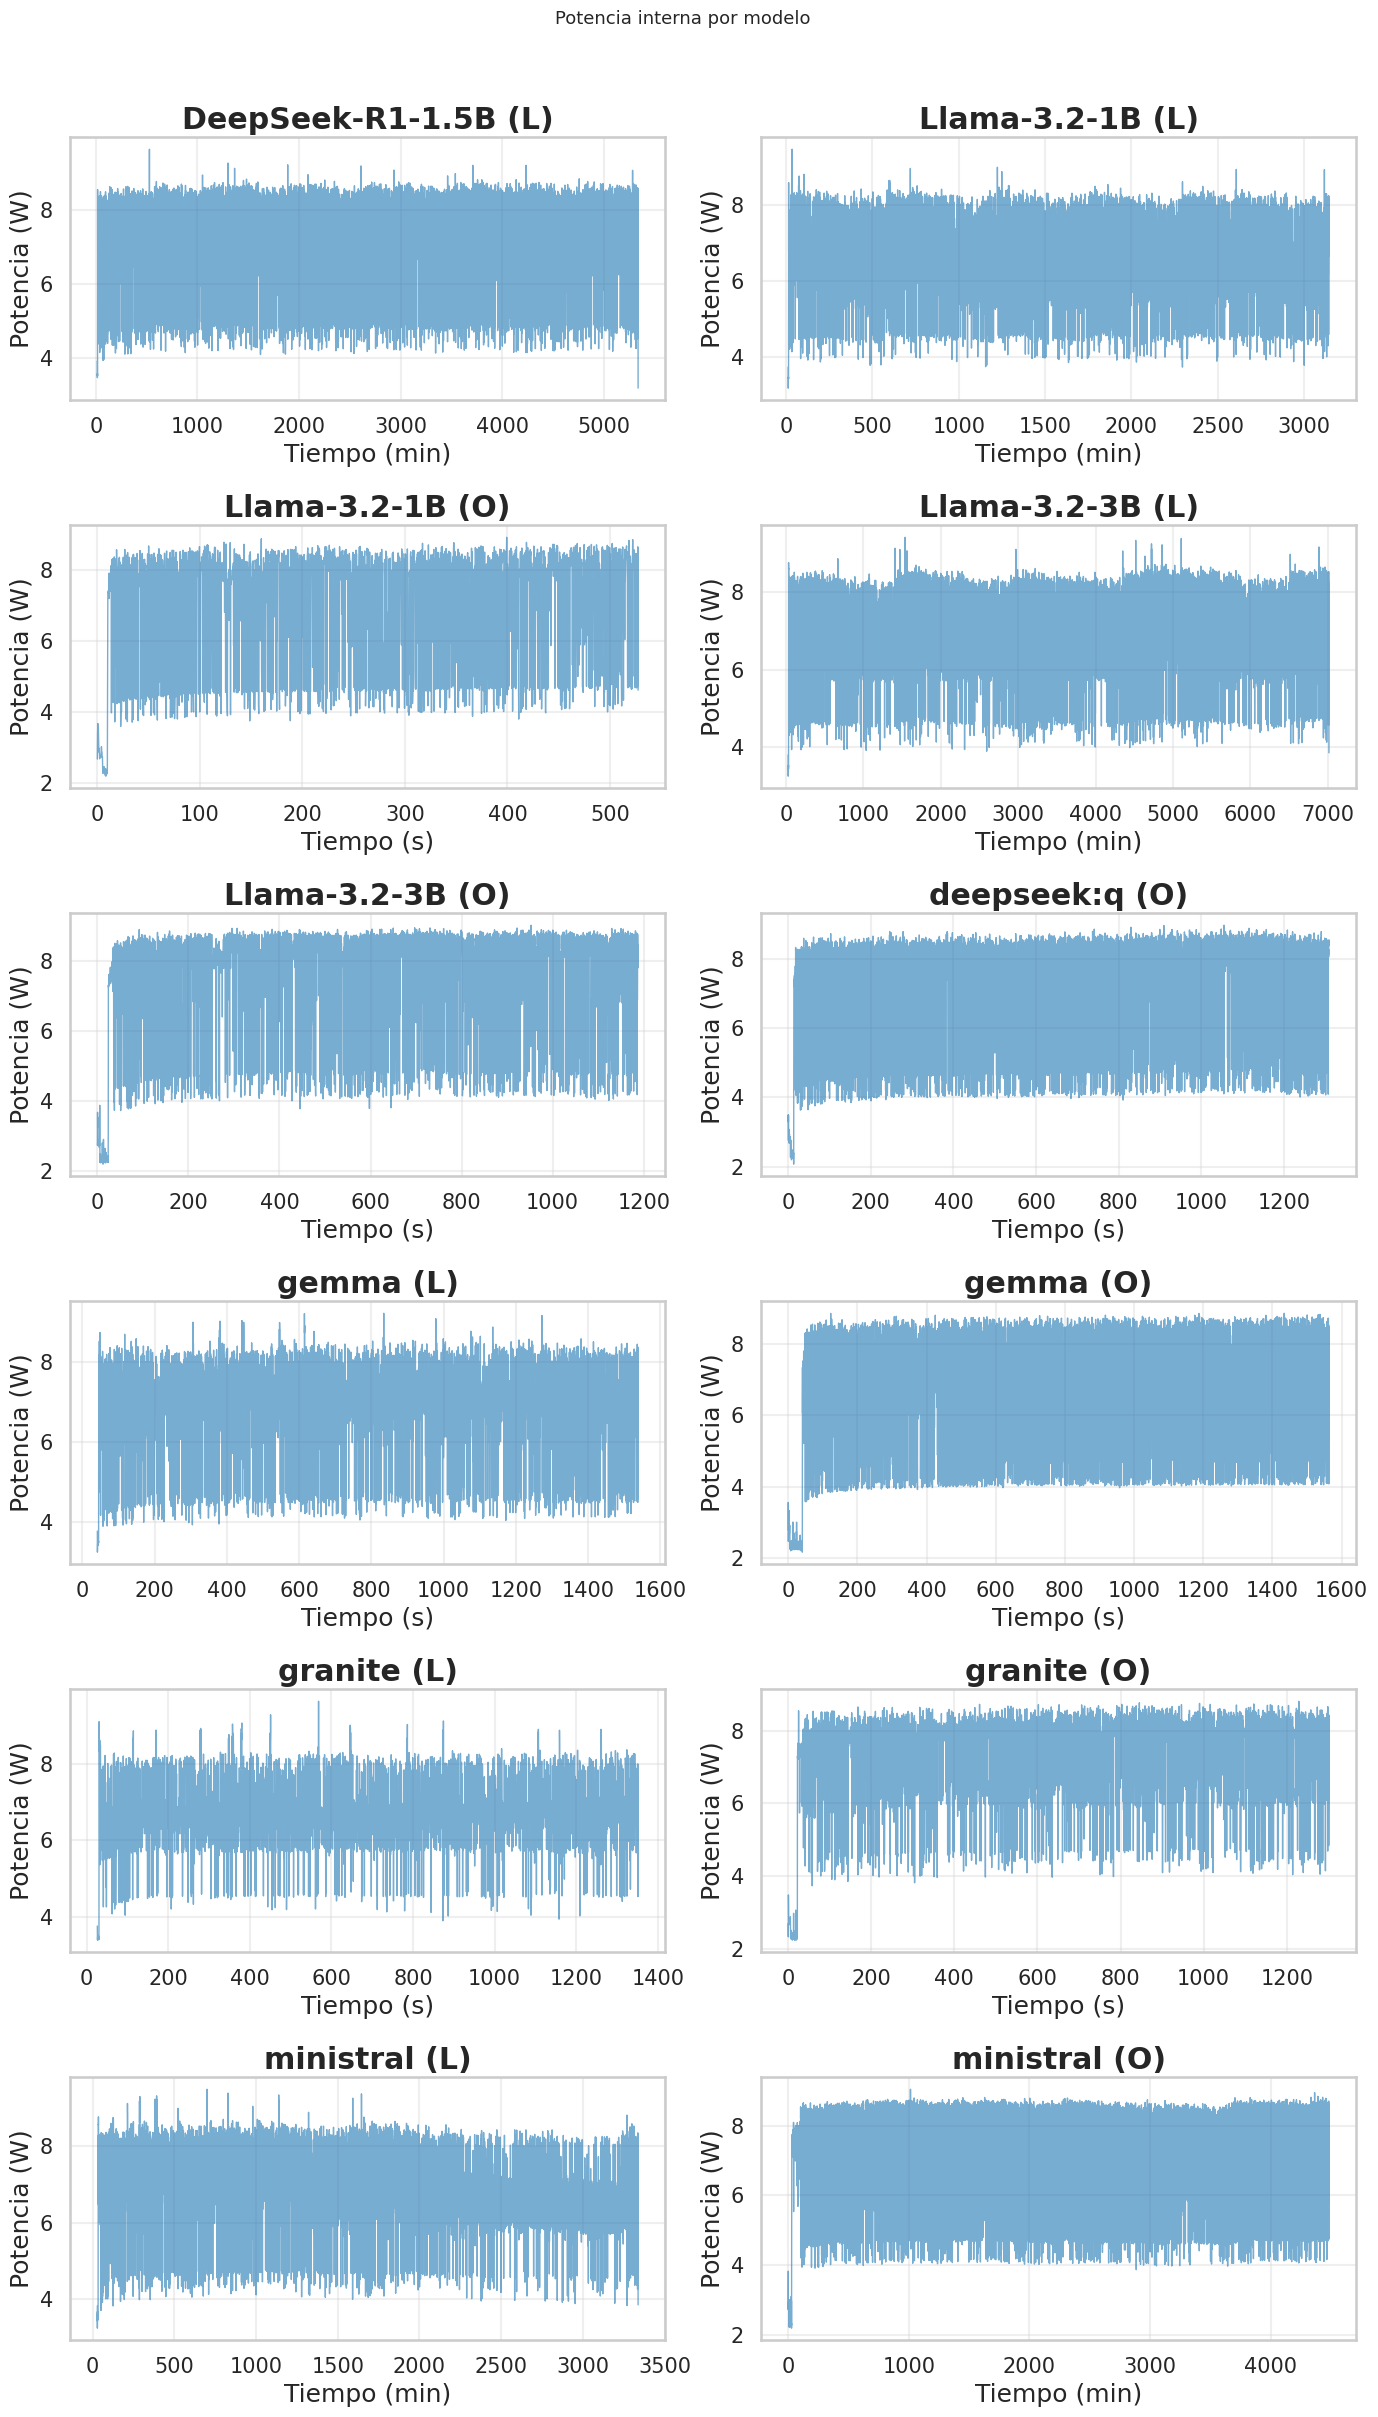

In [8]:
# Timelines de temperatura y potencia (small multiples, 2 columnas)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

def _plot_timeline(hw_ex, models, y_col, ylabel, suptitle, hline=None):
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        # Plot each run separately (fast matplotlib lines, no seaborn aggregation)
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub[y_col].values, alpha=0.6, linewidth=1)
        if hline is not None:
            ax.axhline(hline, ls="--", color="red", alpha=0.5)
        total_s = hw_m["t_rel_s"].max()
        ax.set_xlabel("Tiempo (min)" if total_s > 1800 else "Tiempo (s)")
        ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    _plot_timeline(hw_ex, models, "temperature_c", "Temperatura (°C)",
                   "Temperatura por modelo", hline=80)
    _plot_timeline(hw_ex, models, "internal_power_w", "Potencia (W)",
                   "Potencia interna por modelo")
else:
    print("Sin datos de hardware para timelines")

/tmp/ipykernel_722152/98568102.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_722152/98568102.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


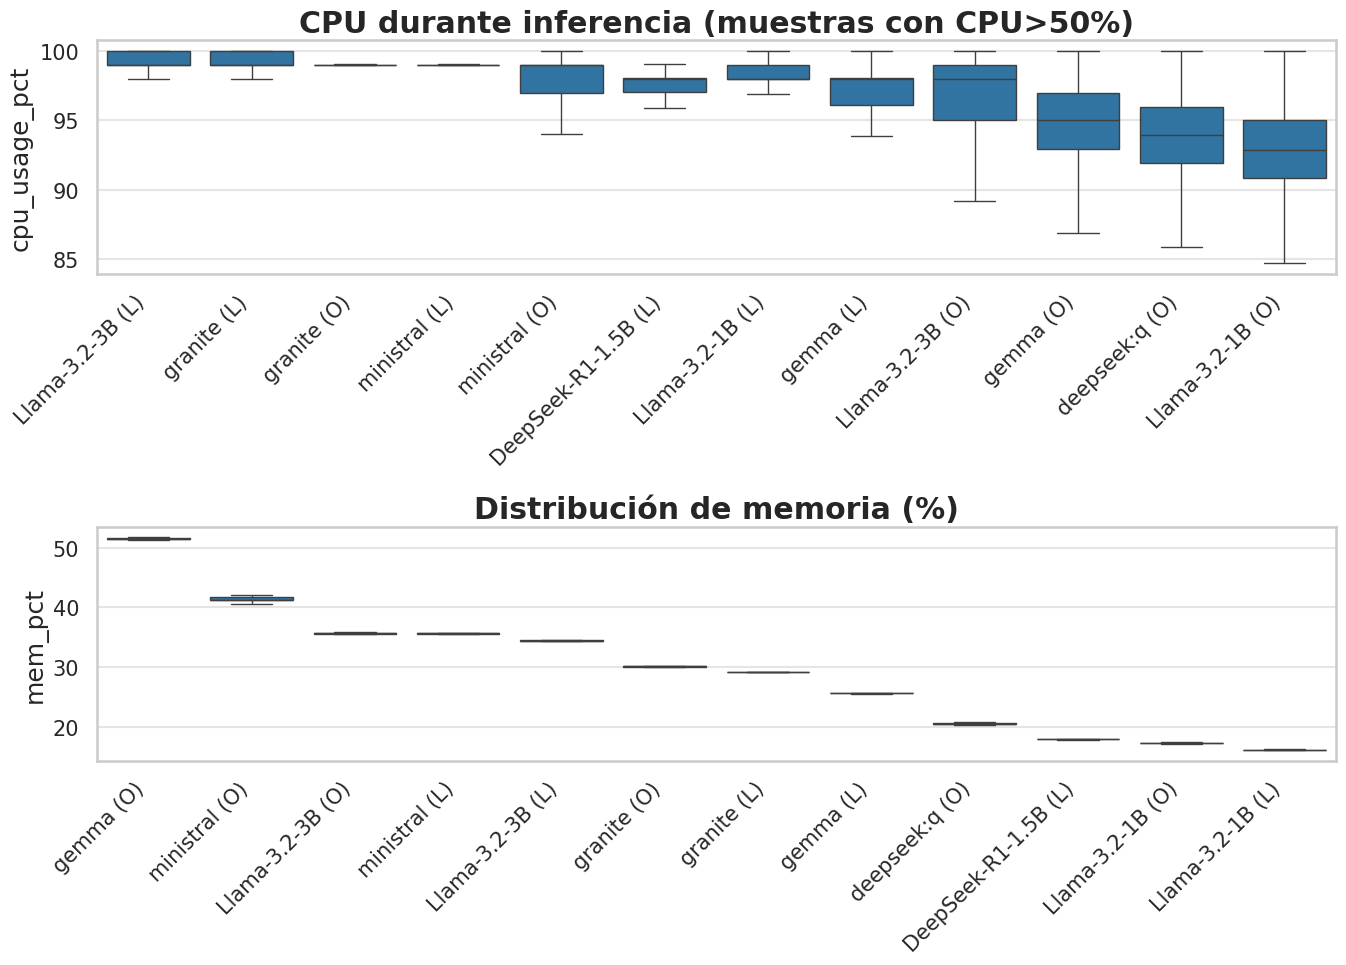

/tmp/ipykernel_722152/98568102.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_722152/98568102.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


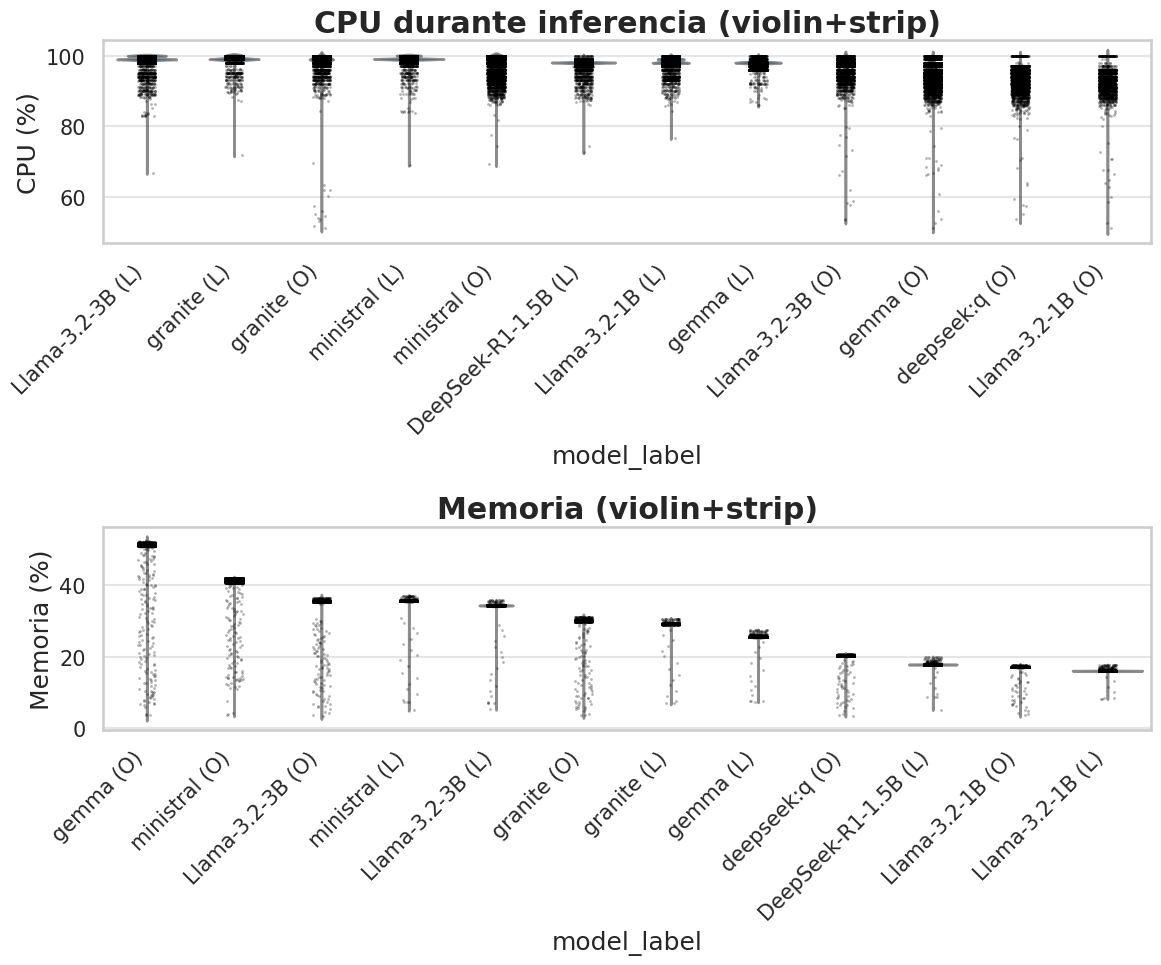

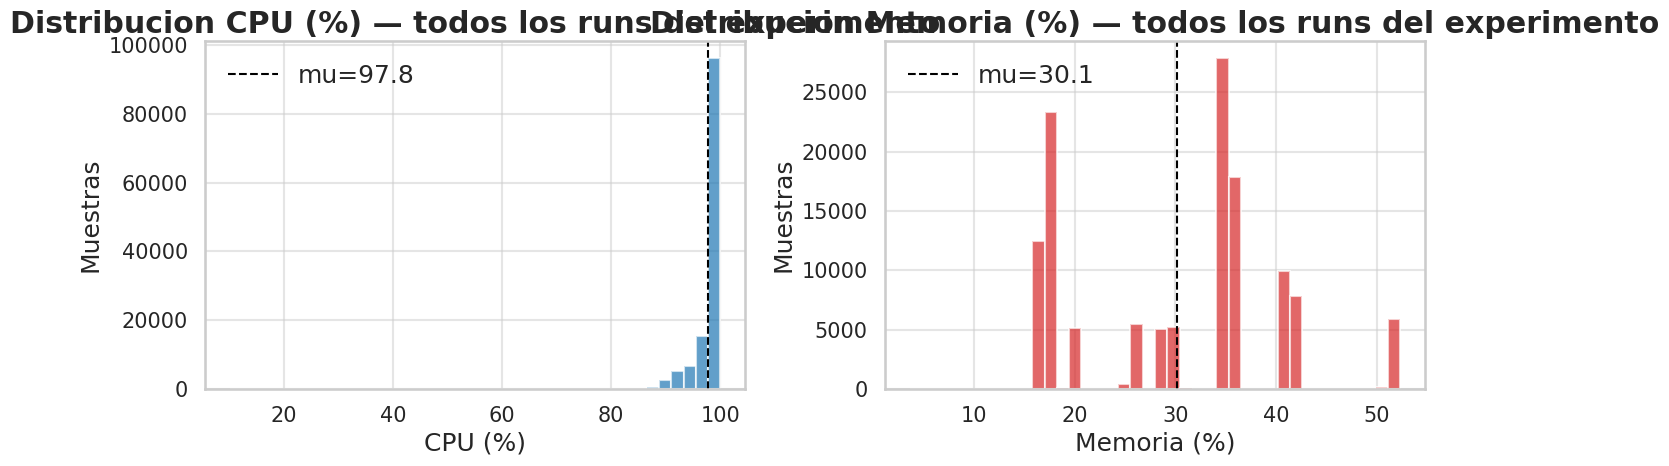

In [9]:
# Sección 5a — Boxplot CPU y Memoria
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=active, x="model_label", y="cpu_usage_pct",
                order=order_cpu, showfliers=False, ax=axes[0])
    axes[0].set_title("CPU durante inferencia (muestras con CPU>50%)")
    axes[0].set_xlabel("")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=hw_ex, x="model_label", y="mem_pct",
                order=order_mem, showfliers=False, ax=axes[1])
    axes[1].set_title("Distribución de memoria (%)")
    axes[1].set_xlabel("")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    fig.tight_layout()
    plt.show()

    # Sección 5b — Violin + strip
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index
                 if not active.empty else [])
    if len(order_cpu) > 0:
        sns.violinplot(data=active, x="model_label", y="cpu_usage_pct",
                       order=order_cpu, inner=None, alpha=0.6, ax=axes[0])
        sns.stripplot(data=active, x="model_label", y="cpu_usage_pct",
                      order=order_cpu, size=2, alpha=0.3, color="black", ax=axes[0])
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
        axes[0].set_title("CPU durante inferencia (violin+strip)")
        axes[0].set_ylabel("CPU (%)")
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index)
    sns.violinplot(data=hw_ex, x="model_label", y="mem_pct",
                   order=order_mem, inner=None, alpha=0.6, ax=axes[1])
    sns.stripplot(data=hw_ex, x="model_label", y="mem_pct",
                  order=order_mem, size=2, alpha=0.3, color="black", ax=axes[1])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].set_title("Memoria (violin+strip)")
    axes[1].set_ylabel("Memoria (%)")
    fig.tight_layout()
    plt.show()

    # Sección 5c — Histogramas agregados
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (col, xlabel, color) in zip(axes, [
        ("cpu_usage_pct", "CPU (%)", "tab:blue"),
        ("mem_pct", "Memoria (%)", "tab:red"),
    ]):
        active_hist = hw_ex[hw_ex["cpu_usage_pct"] > 10]
        data = active_hist[col].dropna()
        if not data.empty:
            ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
            ax.axvline(data.mean(), color='black', ls='--', lw=1.5,
                       label=f"mu={data.mean():.1f}")
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Muestras")
            ax.set_title(f"Distribucion {xlabel} — todos los runs del experimento")
            ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para distribuciones CPU/Memoria")

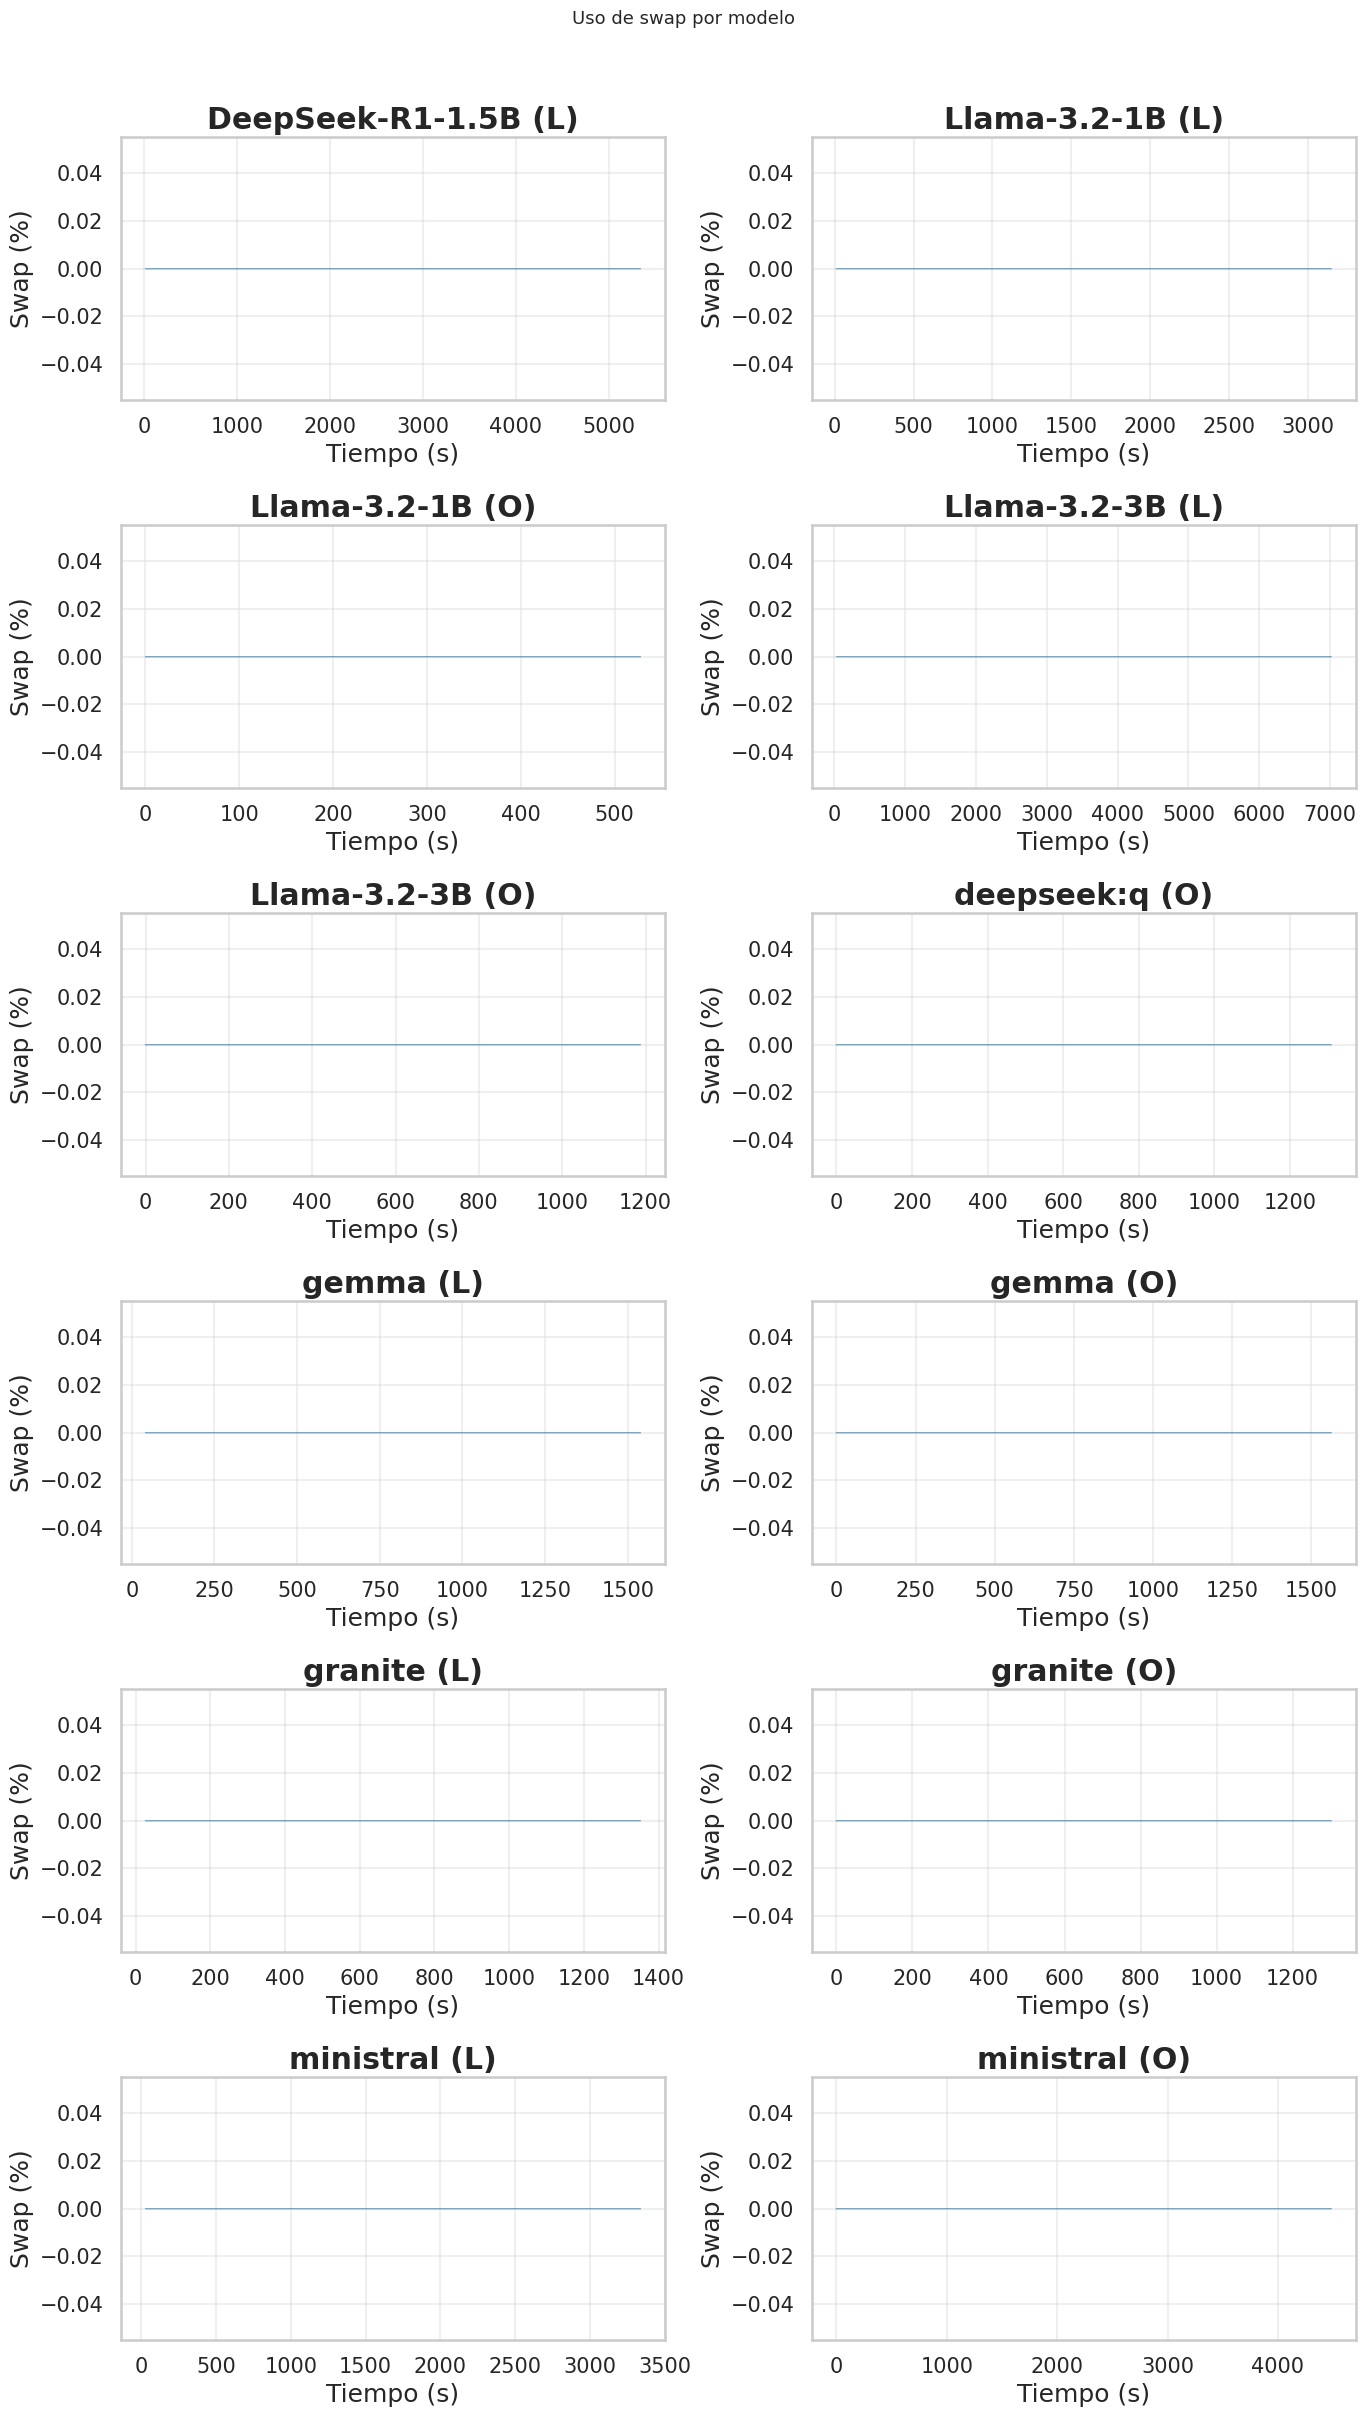

In [10]:
# Swap por modelo (small multiples)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub["swap_pct"].values, alpha=0.6, linewidth=1)
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel("Swap (%)")
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle("Uso de swap por modelo", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para swap")

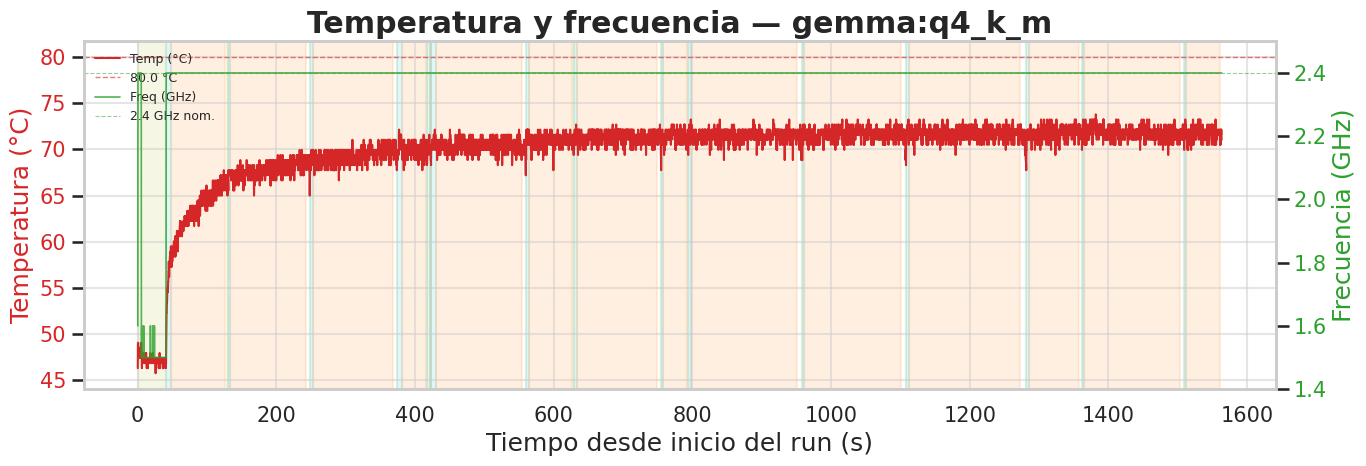

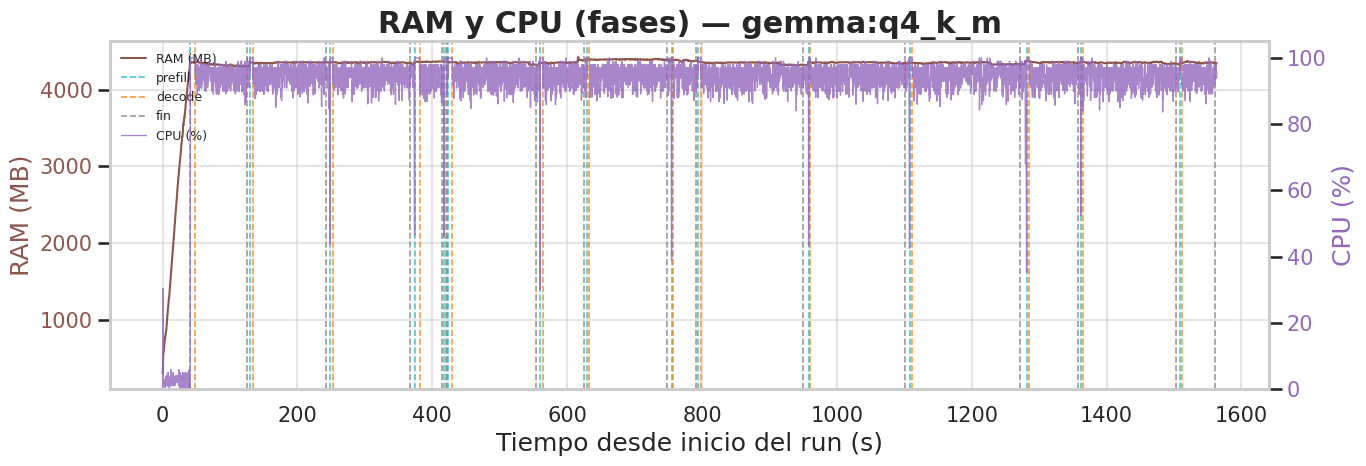

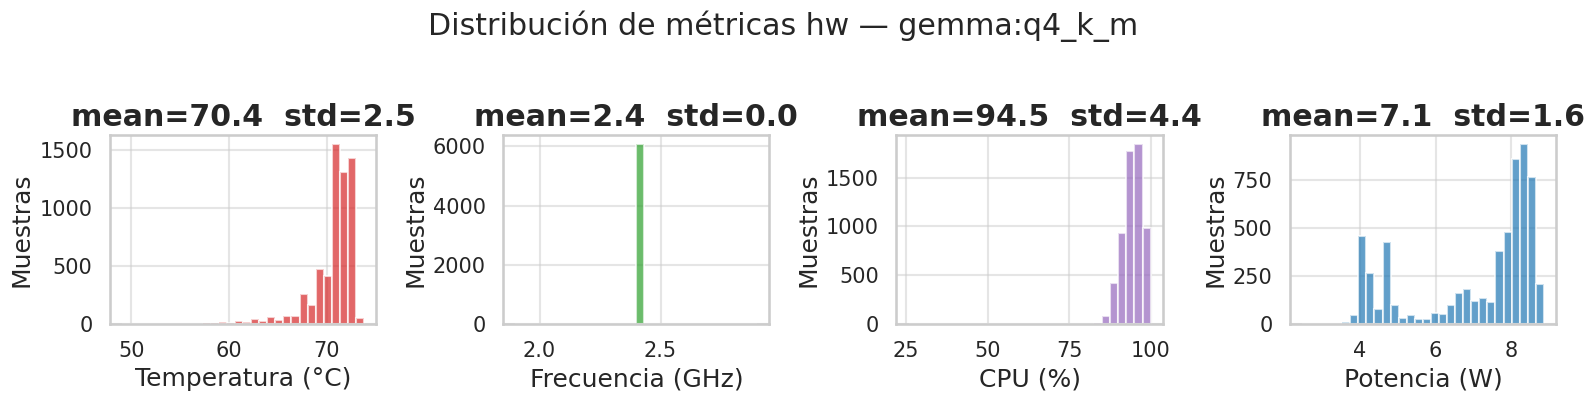

In [11]:
# Análisis detallado de un run representativo (mediana de duración)
from monitorviz.viz import temp_freq_dual, cpu_memory_dual_phases, hw_distributions_panel

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty and len(ex) > 0:
    run_durations = hw_ex.groupby("run_id")["t_rel_s"].max().sort_values()
    median_idx = len(run_durations) // 2
    representative_run_id = run_durations.index[median_idx]
    representative_run = next((r for r in coll.runs if r.run_id == representative_run_id), None)
    if representative_run:
        hw_r = hw_ex[hw_ex["run_id"] == representative_run_id]
        try:
            fig = temp_freq_dual(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"temp_freq_dual: {e}")
        try:
            fig = cpu_memory_dual_phases(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"cpu_memory_dual_phases: {e}")
        try:
            fig = hw_distributions_panel(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"hw_distributions_panel: {e}")
    else:
        print("No se encontro run representativo")
else:
    print("Sin datos para análisis detallado")

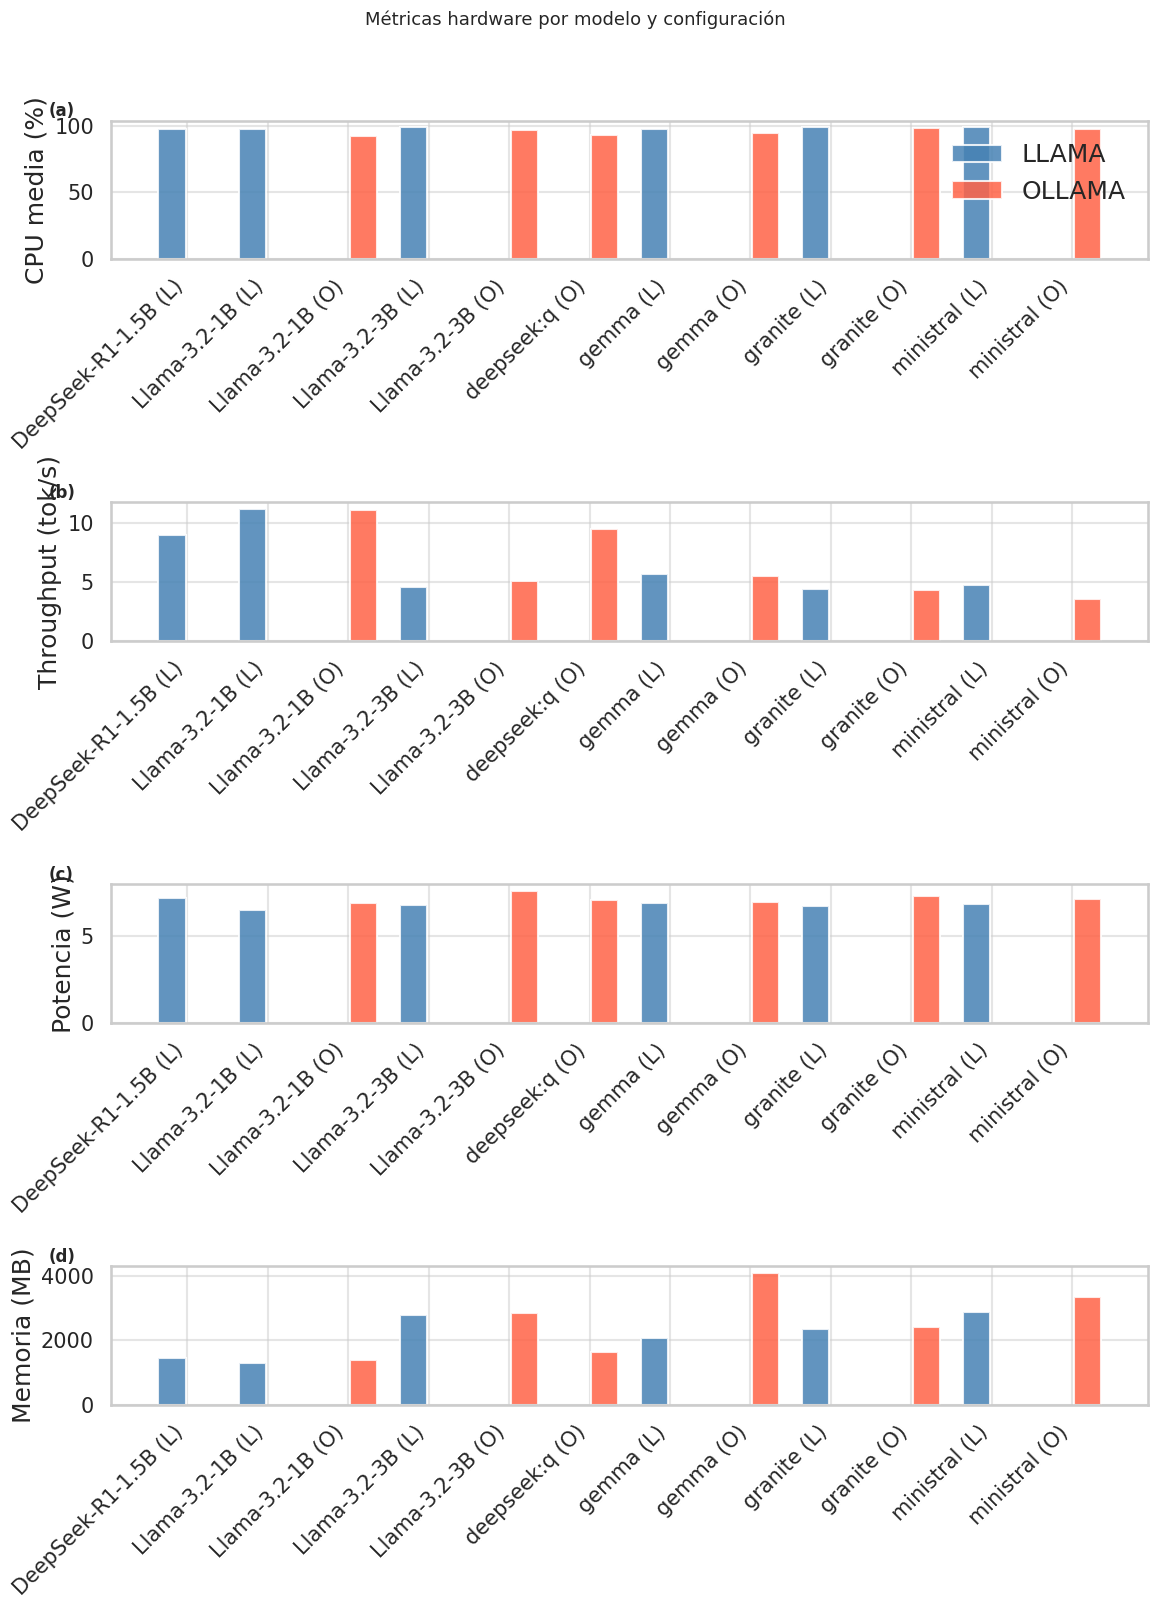

In [12]:
# Grouped bar chart hardware (4 paneles: CPU%, Throughput, Potencia, Memoria)
import re

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

hw_summary_rows = []
pm_valid_tmp = (pm_full[
    (pm_full["run_id"].isin(_run_ids)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
] if "run_id" in pm_full.columns else pd.DataFrame())
for _, row in ex.iterrows():
    if "run_id" not in row.index:
        continue
    hw_r = hw_ex[hw_ex["run_id"] == row["run_id"]] if "run_id" in hw_ex.columns else pd.DataFrame()
    pm_r = pm_valid_tmp[pm_valid_tmp["run_id"] == row["run_id"]] if "run_id" in pm_valid_tmp.columns else pd.DataFrame()
    if hw_r.empty:
        continue
    active_r = hw_r[hw_r["cpu_usage_pct"] > 50]
    group_label = str(row.get("engine", "?"))
    hw_summary_rows.append({
        "model": row["model_label"],
        "config": group_label,
        "cpu_pct": active_r["cpu_usage_pct"].mean() if not active_r.empty else float("nan"),
        "tokens_s": pm_r["tokens_per_second"].mean() if not pm_r.empty else float("nan"),
        "power_w": hw_r["internal_power_w"].mean(),
        "mem_mb": hw_r["mem_used_bytes"].mean() / (1024**2) if not hw_r.empty else float("nan"),
    })

if hw_summary_rows:
    hw_summary = pd.DataFrame(hw_summary_rows)
    METRICS = [
        ("cpu_pct",  "CPU media (%)",      "(a)"),
        ("tokens_s", "Throughput (tok/s)", "(b)"),
        ("power_w",  "Potencia (W)",       "(c)"),
        ("mem_mb",   "Memoria (MB)",       "(d)"),
    ]
    models  = sorted(hw_summary["model"].unique())
    configs = sorted(hw_summary["config"].unique())
    x_pos   = np.arange(len(models))
    n_cfg   = len(configs)
    width   = 0.75 / max(n_cfg, 1)
    colors  = ["steelblue", "tomato", "seagreen", "goldenrod"]
    fig, axes = plt.subplots(len(METRICS), 1, figsize=(12, 4 * len(METRICS)))
    for i, (ax, (col, ylabel, label)) in enumerate(zip(axes, METRICS)):
        data = hw_summary.dropna(subset=[col])
        for j, (cfg, color) in enumerate(zip(configs, colors)):
            vals = [data[(data["model"] == m) & (data["config"] == cfg)][col].mean()
                    for m in models]
            offset = (j - n_cfg / 2 + 0.5) * width
            ax.bar(x_pos + offset, vals, width * 0.9, label=cfg, color=color, alpha=0.85)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.text(-0.06, 1.03, label, transform=ax.transAxes, fontweight="bold", fontsize=12)
        if col == "cpu_pct":
            ax.legend(loc="upper right")
    fig.suptitle("Métricas hardware por modelo y configuración", y=1.01, fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para grouped bar chart hardware")

/tmp/ipykernel_722152/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


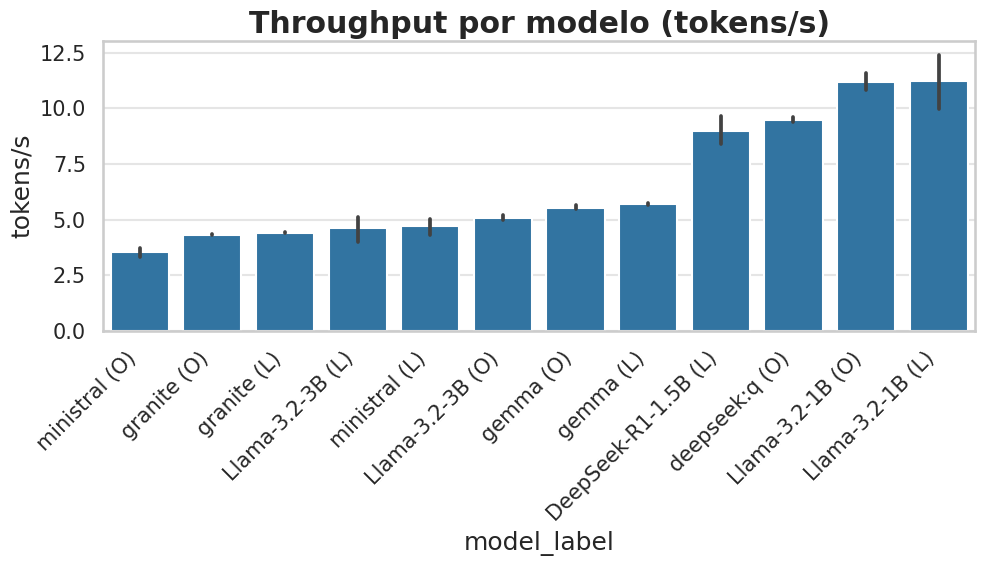

/tmp/ipykernel_722152/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


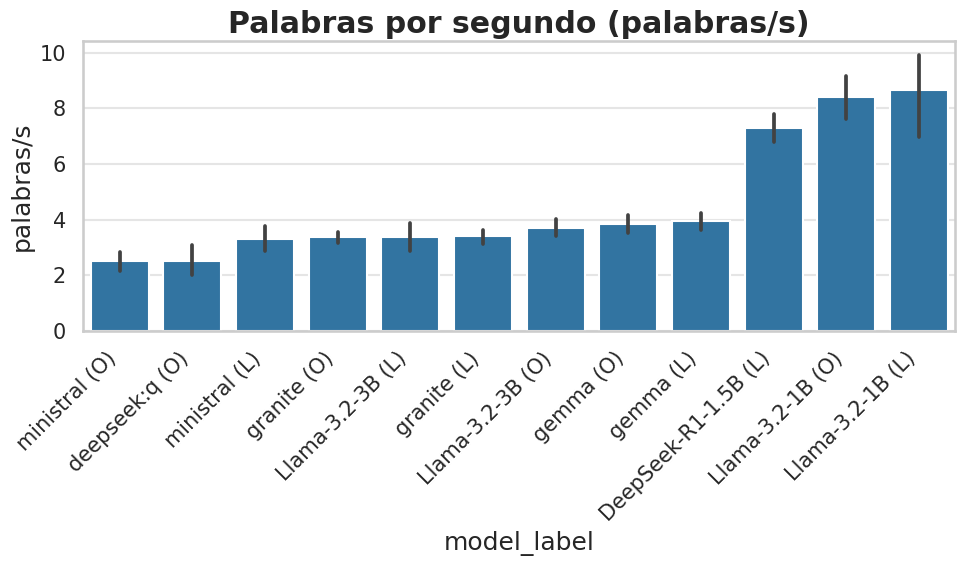

/tmp/ipykernel_722152/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


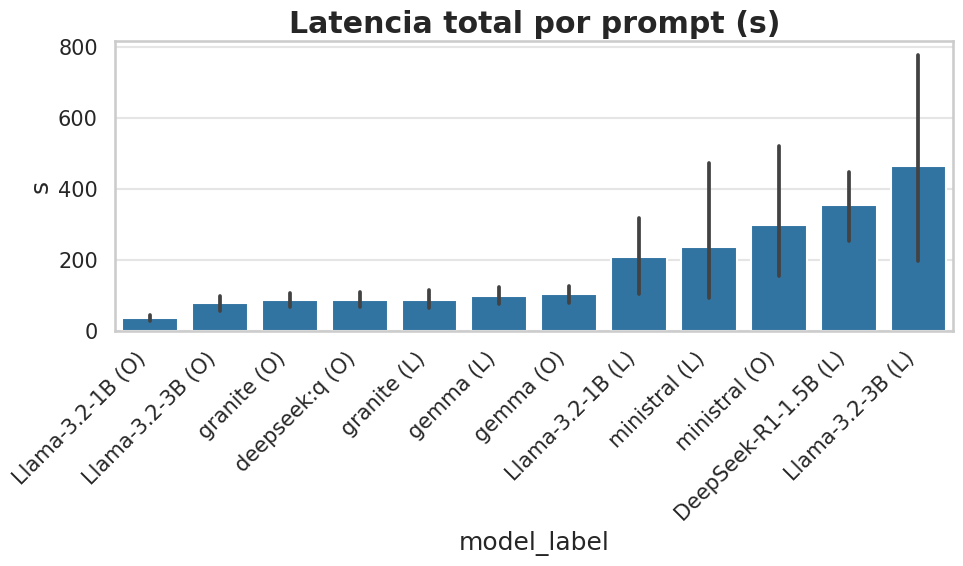

/tmp/ipykernel_722152/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


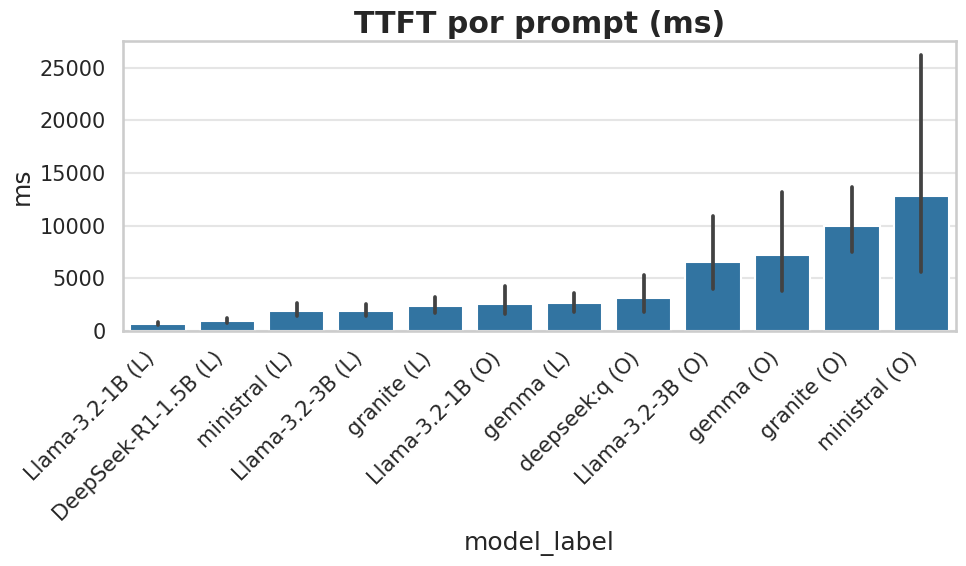

/tmp/ipykernel_722152/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


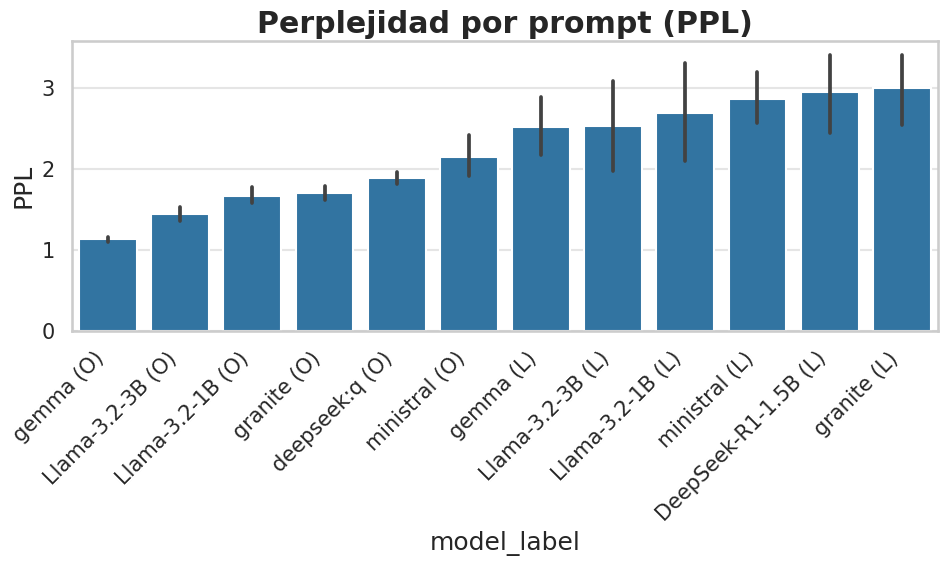

In [13]:
# Métricas de inferencia por modelo
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    _plot_metric(pm_valid, "tokens_per_second", "tokens/s", "Throughput por modelo",
                 unit_label="tokens/s")
    _plot_metric(pm_valid, "words_per_second", "palabras/s", "Palabras por segundo",
                 unit_label="palabras/s")
    _plot_metric(pm_valid, "latency_ms", "ms", "Latencia total por prompt",
                 unit_divisor=1000, unit_label="s")
    _plot_metric(pm_valid, "time_to_first_token_ms", "ms", "TTFT por prompt",
                 unit_label="ms")
    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        _plot_metric(ppl_valid, "perplexity", "", "Perplejidad por prompt",
                     unit_label="PPL")
else:
    print("Sin datos de inferencia")

/tmp/ipykernel_722152/870363815.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


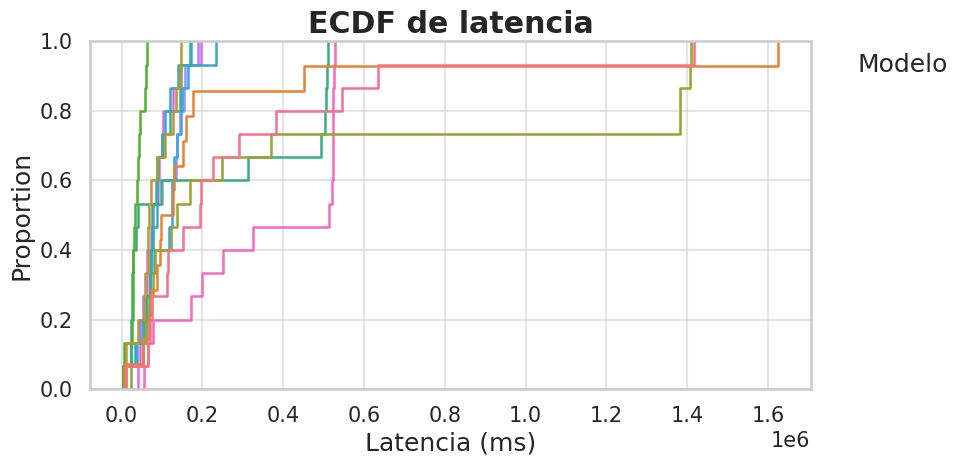

/tmp/ipykernel_722152/870363815.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


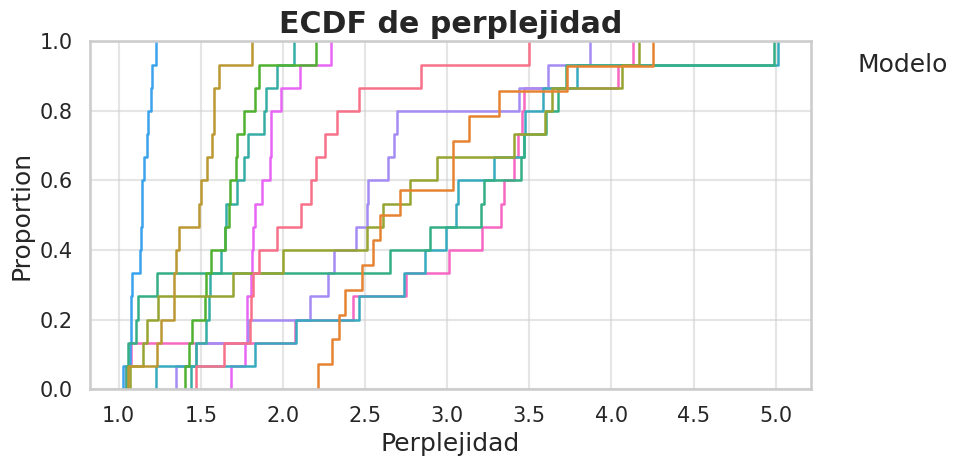

In [14]:
# ECDFs de latencia y perplejidad
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.ecdfplot(data=pm_valid, x="latency_ms", hue="model_label", ax=ax)
    ax.set_title("ECDF de latencia")
    ax.set_xlabel("Latencia (ms)")
    ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    fig.tight_layout()
    plt.show()

    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.ecdfplot(data=ppl_valid, x="perplexity", hue="model_label", ax=ax)
        ax.set_title("ECDF de perplejidad")
        ax.set_xlabel("Perplejidad")
        ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        plt.show()
else:
    print("Sin datos para ECDFs")

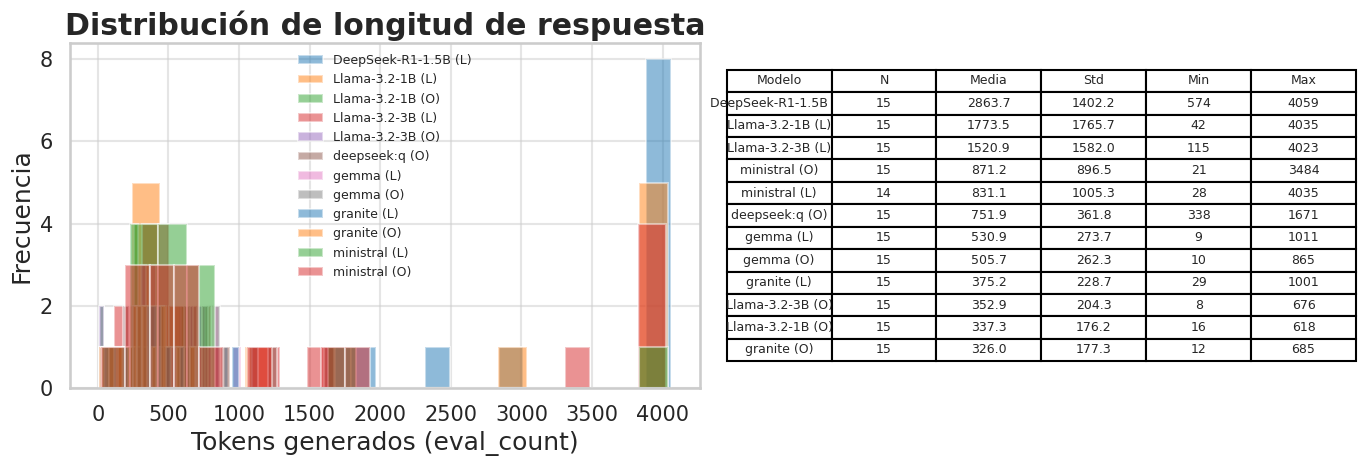

In [15]:
# Distribución de longitud de respuesta
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model in sorted(pm_valid["model_label"].unique()):
        sub = pm_valid[pm_valid["model_label"] == model]
        axes[0].hist(sub["eval_count"], bins=20, alpha=0.5, label=model)
    axes[0].set_xlabel("Tokens generados (eval_count)")
    axes[0].set_ylabel("Frecuencia")
    axes[0].set_title("Distribución de longitud de respuesta")
    axes[0].legend(fontsize=9)
    summary_resp = pm_valid.groupby("model_label")["eval_count"].agg(
        count="count", mean="mean", std="std", min="min", max="max"
    ).round(1).sort_values("mean", ascending=False)
    axes[1].axis("off")
    table_data = [["Modelo", "N", "Media", "Std", "Min", "Max"]]
    for idx, row in summary_resp.iterrows():
        table_data.append([idx, int(row["count"]), f"{row['mean']:.1f}",
                           f"{row['std']:.1f}", f"{row['min']:.0f}", f"{row['max']:.0f}"])
    t = axes[1].table(cellText=table_data, loc="center", cellLoc="center")
    t.auto_set_font_size(False)
    t.set_fontsize(9)
    t.scale(1, 1.5)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para distribución de longitud de respuesta")

Comparativa OLLAMA vs LLAMA.cpp:


energy_per_token_j        tokens_per_s_mean        ttft_ms_mean          
engine                            LLAMA OLLAMA             LLAMA OLLAMA        LLAMA    OLLAMA
model_label                                                                                   
DeepSeek-R1-1.5B (L)               0.80    NaN              8.98    NaN       951.22       NaN
Llama-3.2-1B (L)                   0.58    NaN             11.23    NaN       672.52       NaN
Llama-3.2-1B (O)                    NaN   0.62               NaN  11.16          NaN   2552.15
Llama-3.2-3B (L)                   1.47    NaN              4.61    NaN      1941.10       NaN
Llama-3.2-3B (O)                    NaN   1.49               NaN   5.08          NaN   6562.95
deepseek:q (O)                      NaN   0.75               NaN   9.49          NaN   3111.09
gemma (L)                          1.21    NaN              5.68    NaN      2612.96       NaN
gemma (O)                           NaN   1.25               NaN   5.54          NaN   7235.88
granite (L)                        1.52    NaN              4.41    NaN      2348.40       NaN
granite (O)                         NaN   1.69               NaN   4.32          NaN   9932.31
ministral (L)                      1.44    NaN              4.73    NaN      1928.82       NaN
ministral (O)                       NaN   2.01               NaN   3.55          NaN  12848.06

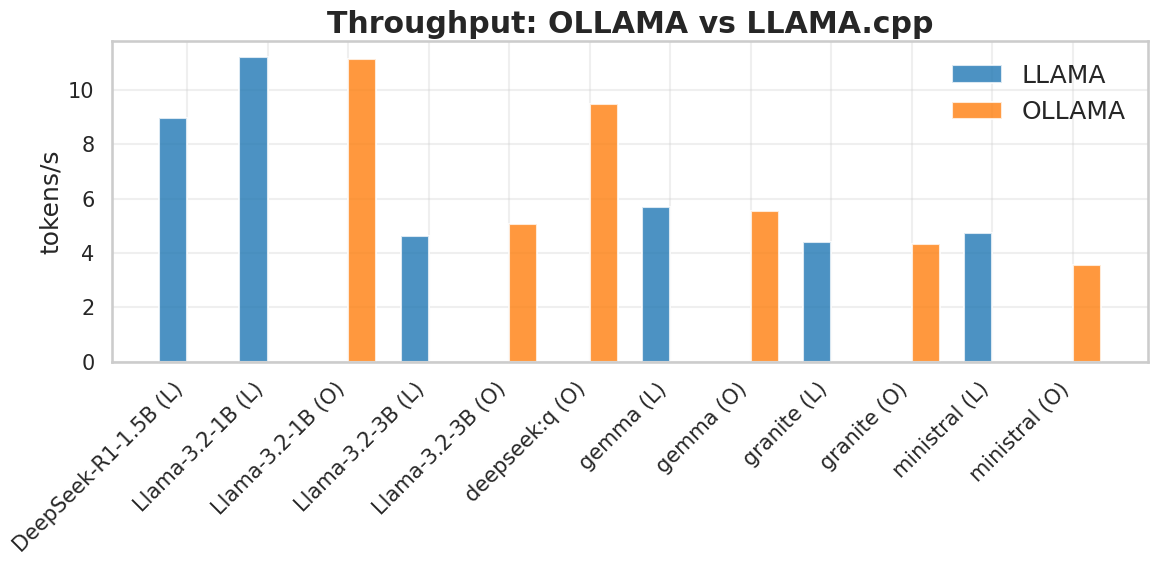

In [16]:
# Análisis específico E4: OLLAMA vs LLAMA.cpp
if "engine" in ex.columns and ex["engine"].nunique() >= 2:
    engine_comp = ex.pivot_table(
        index="model_label", columns="engine",
        values=["tokens_per_s_mean", "ttft_ms_mean", "energy_per_token_j"],
        aggfunc="mean"
    ).round(2)
    print("Comparativa OLLAMA vs LLAMA.cpp:")
    display(engine_comp)

    ollama = ex[ex["engine"] == "OLLAMA"]
    llama  = ex[ex["engine"] == "LLAMA"]
    rows = []
    for m in ex["model_label"].unique():
        o = ollama[ollama["model_label"] == m]
        l = llama[llama["model_label"] == m]
        if not o.empty and not l.empty:
            o_tps = o["tokens_per_s_mean"].mean()
            l_tps = l["tokens_per_s_mean"].mean()
            rows.append({"Modelo": m,
                         "OLLAMA (tok/s)": o_tps, "LLAMA (tok/s)": l_tps,
                         "Overhead TPS %": (l_tps - o_tps) / l_tps * 100 if l_tps > 0 else float("nan")})
    if rows:
        display(pd.DataFrame(rows).round(2))

    if not ex.empty:
        fig, ax = plt.subplots(figsize=(12, 6))
        engines = sorted(ex["engine"].unique())
        models  = sorted(ex["model_label"].unique())
        x = np.arange(len(models))
        w = 0.35
        for i, eng in enumerate(engines):
            vals = [ex[(ex["model_label"] == m) & (ex["engine"] == eng)]["tokens_per_s_mean"].mean()
                    for m in models]
            ax.bar(x + i * w - w / 2, vals, w, label=eng, alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylabel("tokens/s")
        ax.set_title("Throughput: OLLAMA vs LLAMA.cpp")
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()
else:
    print("Sin datos de engines multiples")

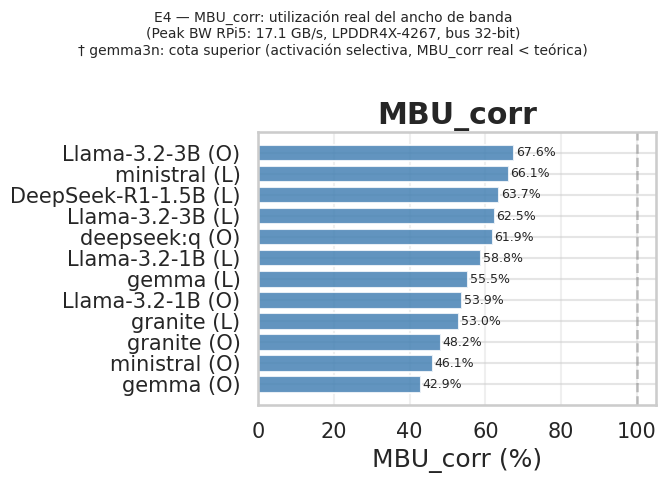

Correcciones aplicadas:


,model_label,mbu_corr,mbu_corr_notes
0,ministral (O),46.12,dense
1,ministral (L),66.13,dense
2,Llama-3.2-3B (O),67.56,dense
3,Llama-3.2-3B (L),62.46,dense
4,Llama-3.2-1B (O),53.89,dense
5,Llama-3.2-1B (L),58.78,dense
6,granite (O),48.17,"Granite SSM hybrid: M_state=74.4 MiB, L_ssm=36..."
7,granite (L),52.96,"Granite SSM hybrid: M_state=74.4 MiB, L_ssm=36..."
8,gemma (O),42.90,Gemma 3n MatFormer: N_params_act=1.910B (verif...
9,gemma (L),55.46,Gemma 3n MatFormer: N_params_act=1.910B (verif...


In [17]:
# MBU_corr — Memory Bandwidth Utilization (arquitectura corregida)
from monitorviz.viz.style import TARGET_PEAK_MEMORY_BANDWIDTH_GBs

_mbu_col = "mbu_corr" if "mbu_corr" in ex.columns else (
           "mbu_pct"  if "mbu_pct"  in ex.columns else None)

if _mbu_col is not None:
    mbu_data = ex.dropna(subset=[_mbu_col]).copy()
    if not mbu_data.empty:
        has_fan = "fan" in mbu_data.columns and mbu_data["fan"].nunique() > 1
        fan_groups = (
            [(True, "Con ventilador (FAN)", "steelblue"),
             (False, "Sin ventilador (NOFAN)", "tomato")]
            if has_fan else [(None, "MBU_corr", "steelblue")]
        )
        fig, axes = plt.subplots(1, len(fan_groups),
                                  figsize=(7 * len(fan_groups), 5), sharey=False)
        if len(fan_groups) == 1:
            axes = [axes]
        for ax, (fan_val, lbl, color) in zip(axes, fan_groups):
            sub = (mbu_data[mbu_data["fan"] == fan_val]
                   if fan_val is not None else mbu_data).copy()
            sub = sub.sort_values(_mbu_col)
            if sub.empty:
                ax.set_axis_off(); continue
            ax.barh(sub["model_label"], sub[_mbu_col], color=color, alpha=0.85)
            ax.axvline(100, ls="--", color="gray", alpha=0.5)
            ax.set_xlabel("MBU_corr (%)")
            ax.set_title(lbl)
            ax.grid(True, axis="x", alpha=0.3)
            for bar, val in zip(ax.patches, sub[_mbu_col]):
                ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                        f"{val:.1f}%", va="center", fontsize=9)
        fig.suptitle(
            f"E4 — MBU_corr: utilización real del ancho de banda\n"
            f"(Peak BW RPi5: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s, LPDDR4X-4267, bus 32-bit)\n"
            "† gemma3n: cota superior (activación selectiva, MBU_corr real < teórica)",
            fontsize=10)
        plt.tight_layout()
        plt.show()
        if "mbu_corr_notes" in mbu_data.columns:
            notes = (mbu_data[["model_label","mbu_corr","mbu_corr_notes"]]
                     .drop_duplicates("model_label").round(2))
            print("Correcciones aplicadas:")
            display(notes)
else:
    print("mbu_corr no disponible en este experimento.")


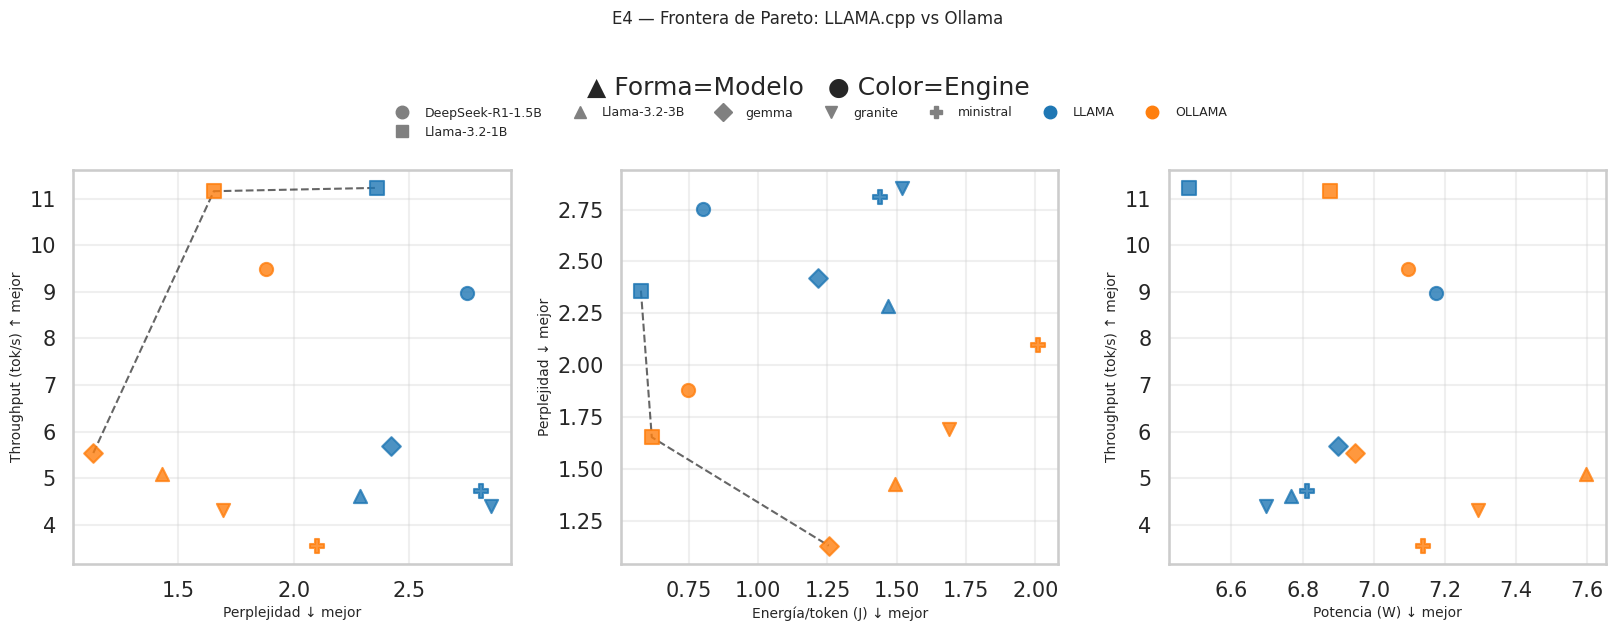

In [18]:
# Trade-offs multidimensionales — Frontera de Pareto (E4)
import re as _re
from matplotlib.lines import Line2D as _L2D

def _pmask4(df, x_col, y_col, x_low, y_low):
    pts = df[[x_col, y_col]].to_numpy(dtype=float)
    dom = np.zeros(len(pts), dtype=bool)
    for i in range(len(pts)):
        for j in range(len(pts)):
            if i == j: continue
            xb = (pts[j,0] <= pts[i,0]) if x_low else (pts[j,0] >= pts[i,0])
            yb = (pts[j,1] <= pts[i,1]) if y_low else (pts[j,1] >= pts[i,1])
            if xb and yb and (pts[j,0] != pts[i,0] or pts[j,1] != pts[i,1]):
                dom[i] = True; break
    return ~dom

try:
    _df4p = ex.copy()
    _df4p["model_base"] = (_df4p["model_label"]
                           .str.replace(r'\s*\([LO]\)\s*', '', regex=True)
                           .str.strip())
    _DEEPSEEK_NORM = {"deepseek:q": "DeepSeek-R1-1.5B", "deepseek-r1:1.5b": "DeepSeek-R1-1.5B"}
    _df4p["model_base"] = _df4p["model_base"].map(lambda x: _DEEPSEEK_NORM.get(x, x))

    _pareto_pairs4 = [
        ("perplexity_geomean", "tokens_per_s_mean",  True,  False, "Perplejidad",       "Throughput (tok/s)"),
        ("energy_per_token_j", "perplexity_geomean",  True,  True,  "Energía/token (J)", "Perplejidad"),
        ("power_mean_w",       "tokens_per_s_mean",   True,  False, "Potencia (W)",      "Throughput (tok/s)"),
    ]
    valid_pairs4 = [(xc,yc,xl,yl,xlab,ylab) for xc,yc,xl,yl,xlab,ylab in _pareto_pairs4
                    if xc in _df4p.columns and yc in _df4p.columns]

    if valid_pairs4 and not _df4p.empty:
        _mbase_p4 = sorted(_df4p["model_base"].unique())
        _MARKERS_P4 = ["o","s","^","D","v","P","X"]
        _MOD_MK_P4  = {m: _MARKERS_P4[i % len(_MARKERS_P4)] for i, m in enumerate(_mbase_p4)}
        _ENG_COL_P4 = {"LLAMA": "tab:blue", "OLLAMA": "tab:orange"}
        _engines_p4 = sorted(_df4p["engine"].dropna().unique()) if "engine" in _df4p.columns else []

        nc4 = len(valid_pairs4)
        fig, axes = plt.subplots(1, nc4, figsize=(nc4 * 5.5, 5.5))
        if nc4 == 1: axes = [axes]

        for ax, (xc, yc, xl, yl, xlabel, ylabel) in zip(axes, valid_pairs4):
            df_p = _df4p.dropna(subset=[xc, yc]).reset_index(drop=True)
            if df_p.empty: ax.set_visible(False); continue

            for model in _mbase_p4:
                for engine in _engines_p4:
                    _sub = df_p[(df_p["model_base"]==model) & (df_p["engine"]==engine)]
                    if _sub.empty: continue
                    ax.scatter(_sub[xc], _sub[yc],
                               marker=_MOD_MK_P4[model],
                               color=_ENG_COL_P4.get(engine, "tab:gray"),
                               s=90, alpha=0.8, zorder=3)

            mask = _pmask4(df_p, xc, yc, xl, yl)
            df_front = df_p[mask].sort_values(xc)
            if not df_front.empty:
                ax.plot(df_front[xc], df_front[yc], "k--", lw=1.5, alpha=0.6)

            ax.set_xlabel(xlabel + (" ↓ mejor" if xl else " ↑ mejor"), fontsize=10)
            ax.set_ylabel(ylabel + (" ↓ mejor" if yl else " ↑ mejor"), fontsize=10)
            ax.grid(True, alpha=0.3)

        _mod_h_p4 = [_L2D([],[],marker=_MOD_MK_P4[m],color="gray",ls="none",ms=9,label=m) for m in _mbase_p4]
        _eng_h_p4 = [_L2D([],[],marker="o",color=_ENG_COL_P4.get(e,"tab:gray"),ls="none",ms=9,label=e) for e in _engines_p4]
        fig.legend(
            handles=_mod_h_p4 + _eng_h_p4,
            loc="upper center", bbox_to_anchor=(0.5, 1.06),
            ncol=min(len(_mbase_p4) + len(_engines_p4), 7), fontsize=9,
            title="▲ Forma=Modelo   ● Color=Engine"
        )
        fig.suptitle("E4 — Frontera de Pareto: LLAMA.cpp vs Ollama", fontsize=12, y=1.16)
        fig.tight_layout()
        plt.show()
    else:
        print("Columnas insuficientes para Pareto")
except Exception as e:
    print(f"Error en Pareto: {e}")


In [19]:
# Desglose de fases (si hay datos)
try:
    from monitorviz.viz import phase_breakdown_stacked
    _run_ids_15 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    pm_valid = (pm_full[
        (pm_full["run_id"].isin(_run_ids_15)) &
        (~pm_full["is_empty_generation"]) &
        (pm_full["latency_ms"] > 0)
    ] if "run_id" in pm_full.columns else pd.DataFrame())
    if not pm_valid.empty and "phase_prompt_s" in pm_valid.columns:
        fig = phase_breakdown_stacked(ex, normalized=True)
        plt.show()
        fig = phase_breakdown_stacked(ex, normalized=False)
        plt.show()
    else:
        print("Sin datos de fases")
except Exception as e:
    print(f"Error en phase_breakdown: {e}")

Sin datos de fases


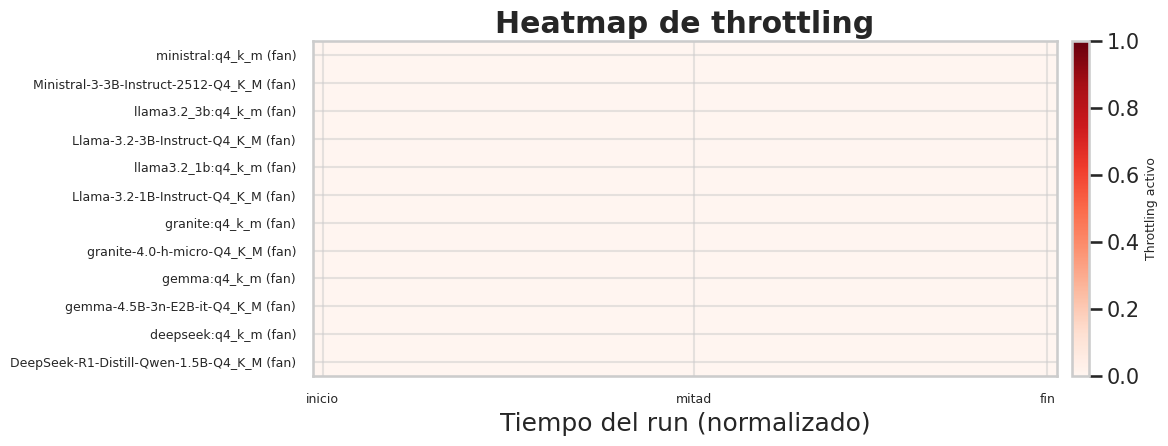

In [20]:
# Throttling heatmap
try:
    from monitorviz.viz import throttling_heatmap
    _run_ids_16 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    hw_ex = hw_full[hw_full["run_id"].isin(_run_ids_16)] if "run_id" in hw_full.columns else pd.DataFrame()
    runs_ex = [r for r in coll.runs if r.run_id in _run_ids_16]
    if hw_ex.empty or not runs_ex:
        print("Sin datos de hardware para heatmap de throttling")
    else:
        fig = throttling_heatmap(hw_ex, runs_ex, bins=40,
                                 title="Heatmap de throttling")
        plt.show()
except Exception as e:
    print(f"Error en throttling_heatmap: {e}")

## Eficiencia computacional: trabajo CPU efectivo

- **W_CPU (core·s)**: integra `(f(t)/f_nom) x (CPU(t)/100) x N_cores x dt`
- **eta_CPU**: W_CPU / (N_cores x T), rango [0,1]
- **W_token (core·s/token)**: trabajo CPU por token generado

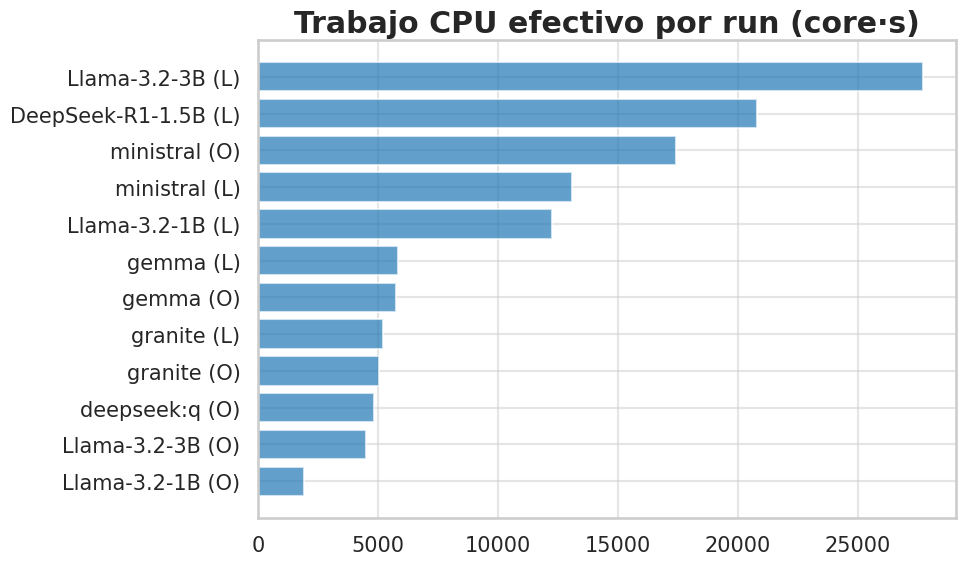

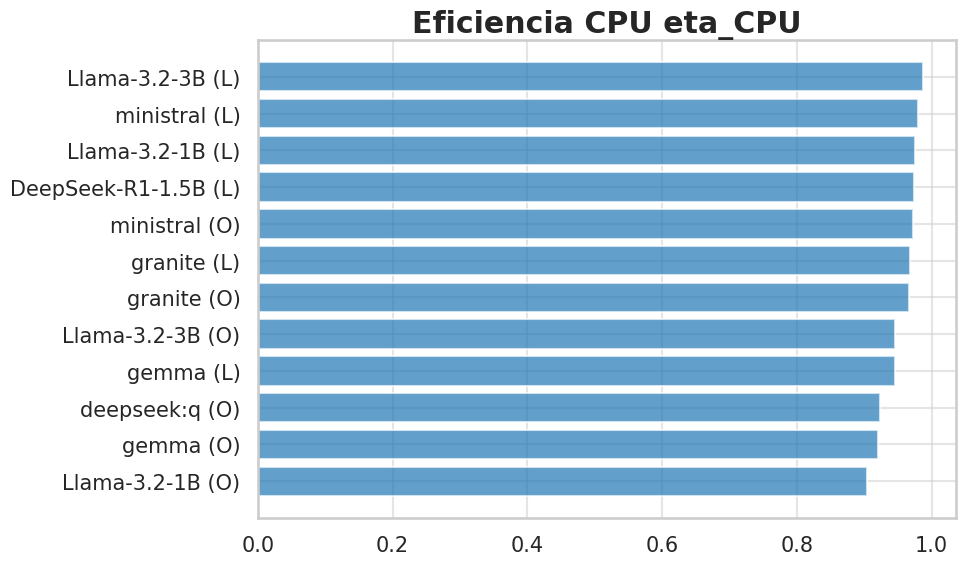

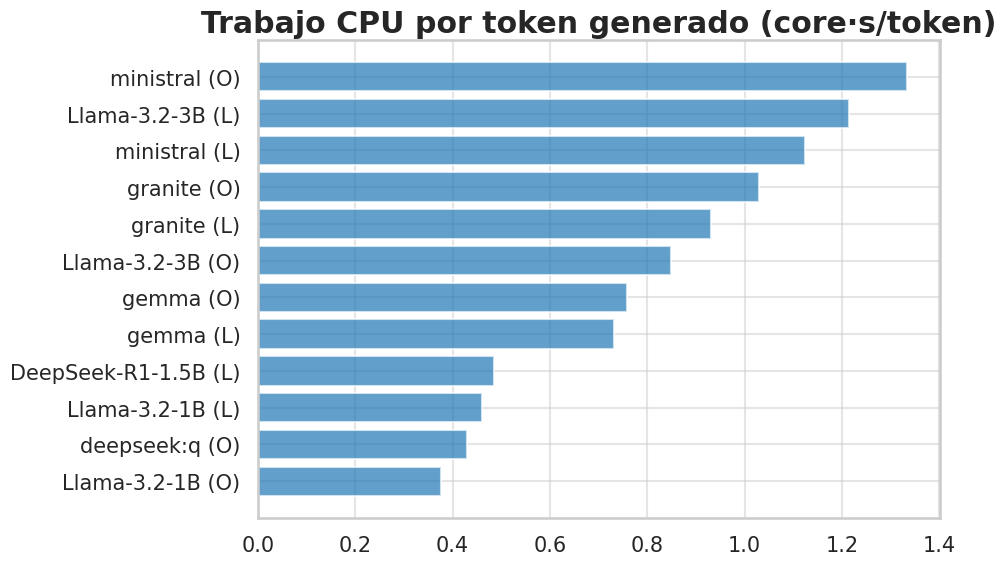

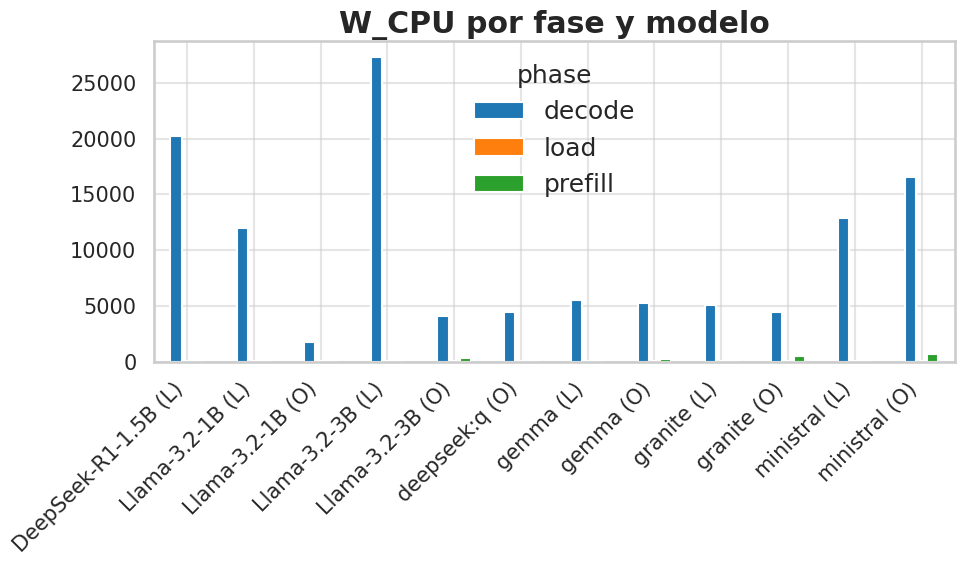

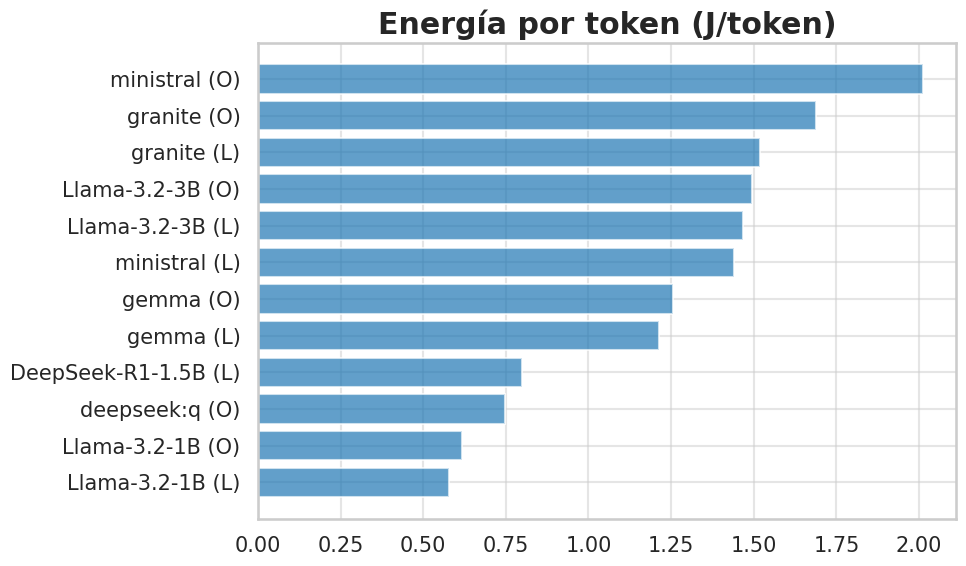

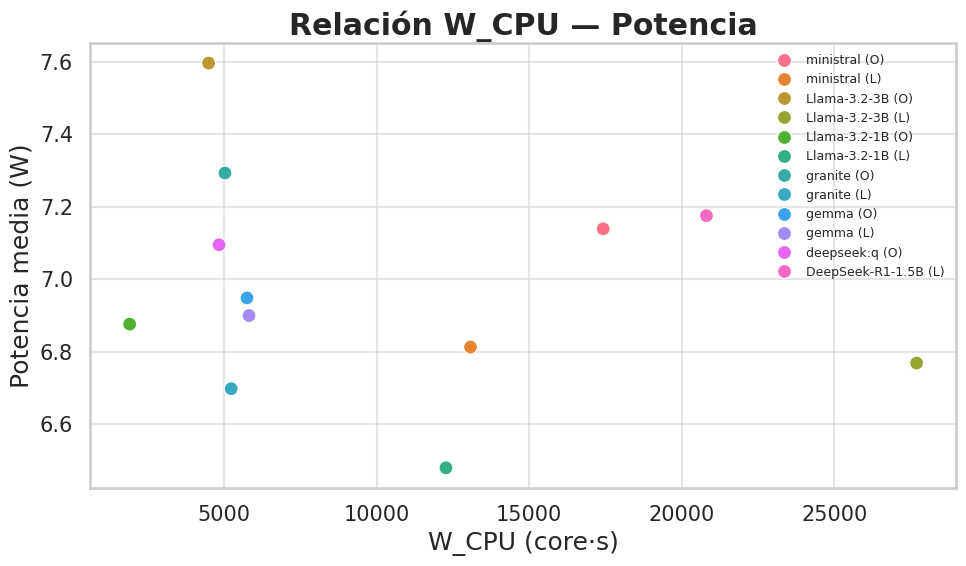

In [21]:
# Eficiencia computacional y energética
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

for col, ylabel, title in [
    ("cpu_work_core_s", "core·s", "Trabajo CPU efectivo por run"),
    ("cpu_efficiency",  "",       "Eficiencia CPU eta_CPU"),
    ("cpu_work_per_token", "core·s/token", "Trabajo CPU por token generado"),
]:
    if col in ex.columns:
        _plot_metric(ex, col, ylabel=ylabel, title=title, unit_label=ylabel)

# Desglose por fases
try:
    phase_df = coll.cpu_work_by_phase_df() if hasattr(coll, "cpu_work_by_phase_df") else pd.DataFrame()
    phase_df_ex = phase_df[phase_df["run_id"].isin(ex["run_id"])] if not phase_df.empty else pd.DataFrame()
    if not phase_df_ex.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        phase_df_ex.groupby(["model_label", "phase"])["cpu_work_core_s"].mean().unstack().plot(
            kind="bar", ax=ax, rot=45)
        ax.set_title("W_CPU por fase y modelo")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        fig.tight_layout()
        plt.show()
except Exception as e:
    print(f"cpu_work_by_phase_df: {e}")

# Energía por token
if "energy_per_token_j" in ex.columns:
    _plot_metric(ex, "energy_per_token_j", "J/token", "Energía por token", unit_label="J/token")

# Scatterplot CPU vs Potencia
if "cpu_work_core_s" in ex.columns and "power_mean_w" in ex.columns:
    valid_data = ex.dropna(subset=["cpu_work_core_s", "power_mean_w"])
    if not valid_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.scatterplot(data=valid_data, x="cpu_work_core_s", y="power_mean_w",
                        hue="model_label", s=100, ax=ax)
        ax.set_xlabel("W_CPU (core·s)")
        ax.set_ylabel("Potencia media (W)")
        ax.set_title("Relación W_CPU — Potencia")
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

In [22]:
# E4/E5: Seccion 18 — sin scatter arquitectura especifico
print("Seccion 18: no aplica análisis de arquitectura especifico para este experimento.")

Seccion 18: no aplica análisis de arquitectura especifico para este experimento.


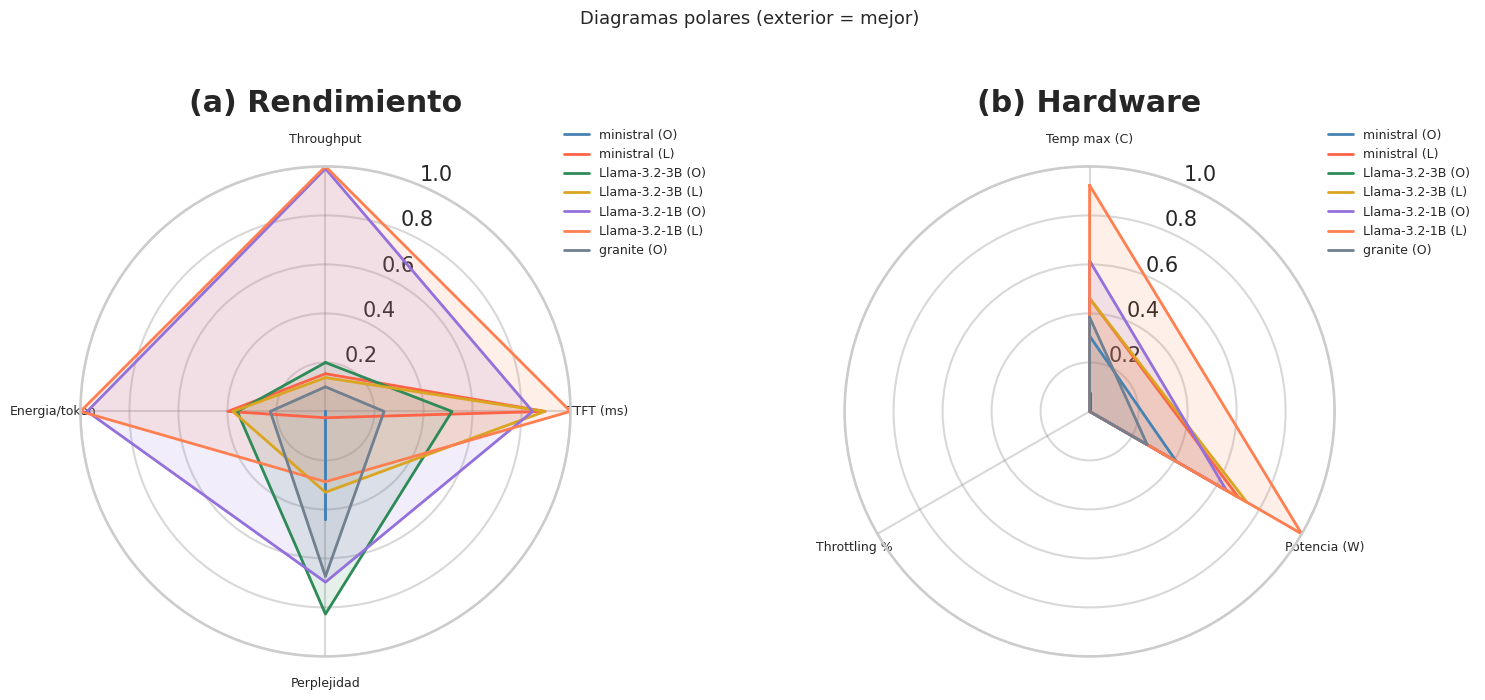

In [23]:
# Diagramas polares (rendimiento y hardware)
def _radar_chart(df, metrics, title, ax, colors):
    cols = [m[0] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        return
    labels = [m[1] for m in metrics]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, 1)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=15, fontweight="bold")
    for (_, row), color in zip(data.iterrows(), colors[:len(data)]):
        vals = []
        for col, _, higher_is_better in metrics:
            col_min, col_max = data[col].min(), data[col].max()
            rng = col_max - col_min if col_max != col_min else 1.0
            vals.append((data.loc[row.name, col] - col_min) / rng if higher_is_better
                        else (col_max - data.loc[row.name, col]) / rng)
        vals += vals[:1]
        ax.plot(angles, vals, lw=2, color=color, label=row["model_label"])
        ax.fill(angles, vals, alpha=0.12, color=color)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

perf_metrics = [
    ("tokens_per_s_mean",  "Throughput",      True),
    ("ttft_ms_mean",       "TTFT (ms)",        False),
    ("perplexity_geomean", "Perplejidad",      False),
    ("energy_per_token_j", "Energia/token",    False),
]
hw_metrics_radar = [
    ("temp_max_c",      "Temp max (C)", False),
    ("power_mean_w",    "Potencia (W)", False),
    ("throttled_ratio", "Throttling %", False),
]
colors_radar = ["steelblue", "tomato", "seagreen", "goldenrod", "mediumpurple", "coral", "slategray"]
fig = plt.figure(figsize=(16, 7))
perf_avail = [m for m in perf_metrics if m[0] in ex.columns]
hw_avail   = [m for m in hw_metrics_radar if m[0] in ex.columns]
if perf_avail:
    ax1 = fig.add_subplot(121, polar=True)
    _radar_chart(ex, perf_avail, "(a) Rendimiento", ax1, colors_radar)
if hw_avail:
    ax2 = fig.add_subplot(122, polar=True)
    _radar_chart(ex, hw_avail, "(b) Hardware", ax2, colors_radar)
fig.suptitle("Diagramas polares (exterior = mejor)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

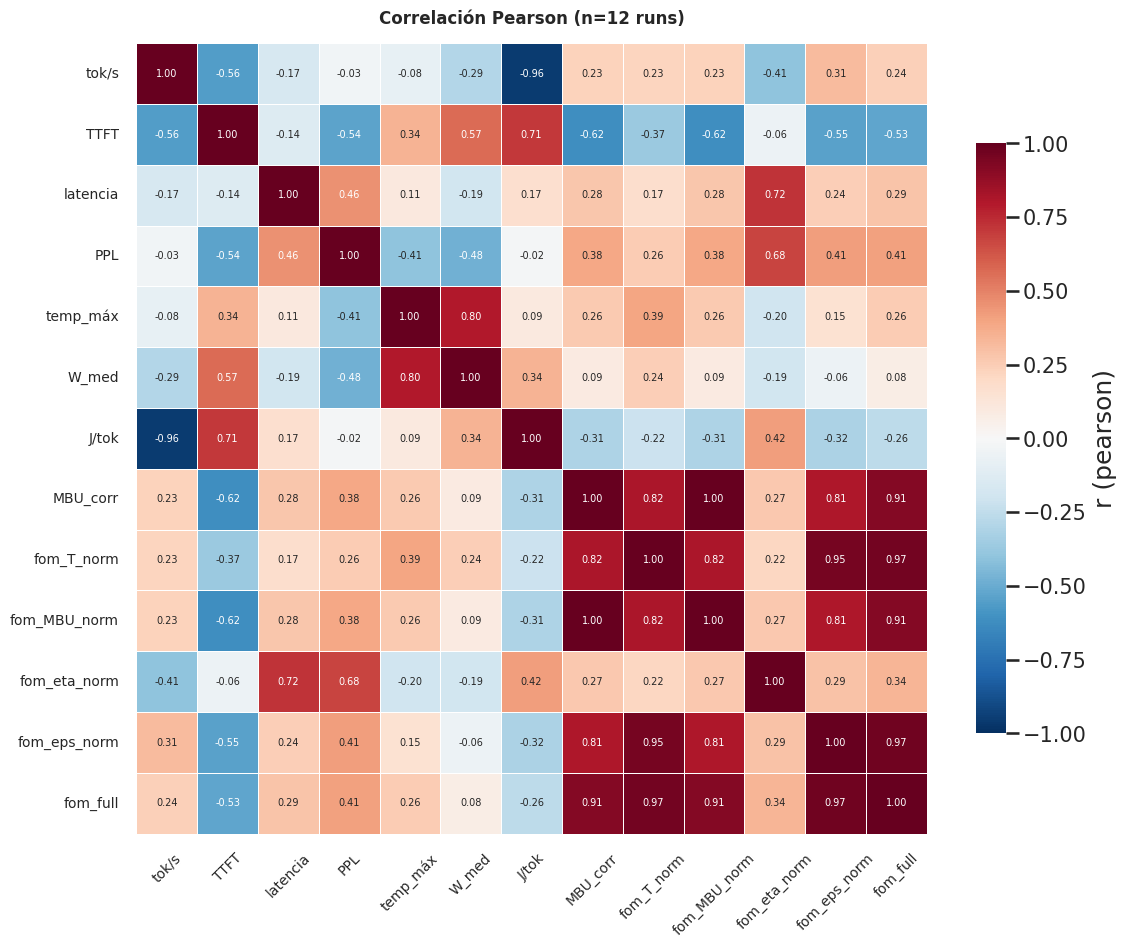

In [24]:
# Correlación de Pearson
try:
    from monitorviz.viz import correlation_heatmap
    from monitorviz.transforms.fom import compute_fom_full
    if len(ex) >= 3:
        _fom_p4 = compute_fom_full(ex)
        _pearson_cols4 = [c for c in [
            "tokens_per_s_mean", "ttft_ms_mean", "latency_ms_mean",
            "perplexity_geomean", "temp_max_c", "power_mean_w",
            "energy_per_token_j", "mbu_corr",
            "fom_T_norm", "fom_MBU_norm", "fom_eta_norm", "fom_eps_norm", "fom_full",
        ] if c in _fom_p4.columns]
        fig = correlation_heatmap(_fom_p4, cols=_pearson_cols4,
                                  title=f"Correlación Pearson (n={len(_fom_p4)} runs)")
        plt.show()
    else:
        print(f"Datos insuficientes: {len(ex)} run(s), se necesitan >=3.")
except Exception as e:
    print(f"Error en correlación: {e}")


In [25]:
# Alertas y anomalías
alerts = []
if "throttled_ratio" in ex.columns:
    for _, row in ex[ex["throttled_ratio"] > 0.5].iterrows():
        alerts.append(f"throttling: {row['model_label']} ({row['throttled_ratio']*100:.1f}%)")
if "n_empty_generations" in ex.columns:
    for _, row in ex[ex["n_empty_generations"] > 0].iterrows():
        alerts.append(f"generaciones vacias: {row['model_label']} (n={int(row['n_empty_generations'])})")
if "tokens_per_s_mean" in ex.columns and len(ex) >= 3:
    mean_tps = ex["tokens_per_s_mean"].mean()
    std_tps  = ex["tokens_per_s_mean"].std()
    for _, row in ex[(ex["tokens_per_s_mean"] > mean_tps + 2 * std_tps) |
                     (ex["tokens_per_s_mean"] < mean_tps - 2 * std_tps)].iterrows():
        alerts.append(f"outlier throughput: {row['model_label']} ({row['tokens_per_s_mean']:.2f} tok/s)")
for a in alerts:
    print(f"ALERTA: {a}")
if not alerts:
    print("Sin alertas detectadas")

ALERTA: generaciones vacias: ministral (L) (n=1)


## Figura de Mérito (FoM_full)

Combina cuatro ejes normalizados respecto a la configuración de referencia
(**llama3.2:3b · llama.cpp · Q4_K_M · ctx=4096 · bs=512**):

$$\text{FoM\_full} = \bigl(T_{norm} \cdot MBU_{norm} \cdot \eta_{norm} \cdot \varepsilon_{norm}\bigr)^{1/4}$$

| Eje | Normalización | Significado |
|-----|--------------|-------------|
| $T_{norm}$ | $N \cdot T / (N_{ref} T_{ref})$ | Throughput ponderado por tamaño |
| $MBU_{norm}$ | $\text{MBU\_corr} / \text{MBU}_{ref}$ | Utilización de ancho de banda (corregida) |
| $\eta_{norm}$ | $\eta_{CPU} / \eta_{ref}$ | Eficiencia computacional |
| $\varepsilon_{norm}$ | $N \cdot \varepsilon / (N_{ref} \varepsilon_{ref})$ | Tokens/J ponderados por tamaño |

**FoM_full > 1** → la configuración supera a la referencia en media geométrica.

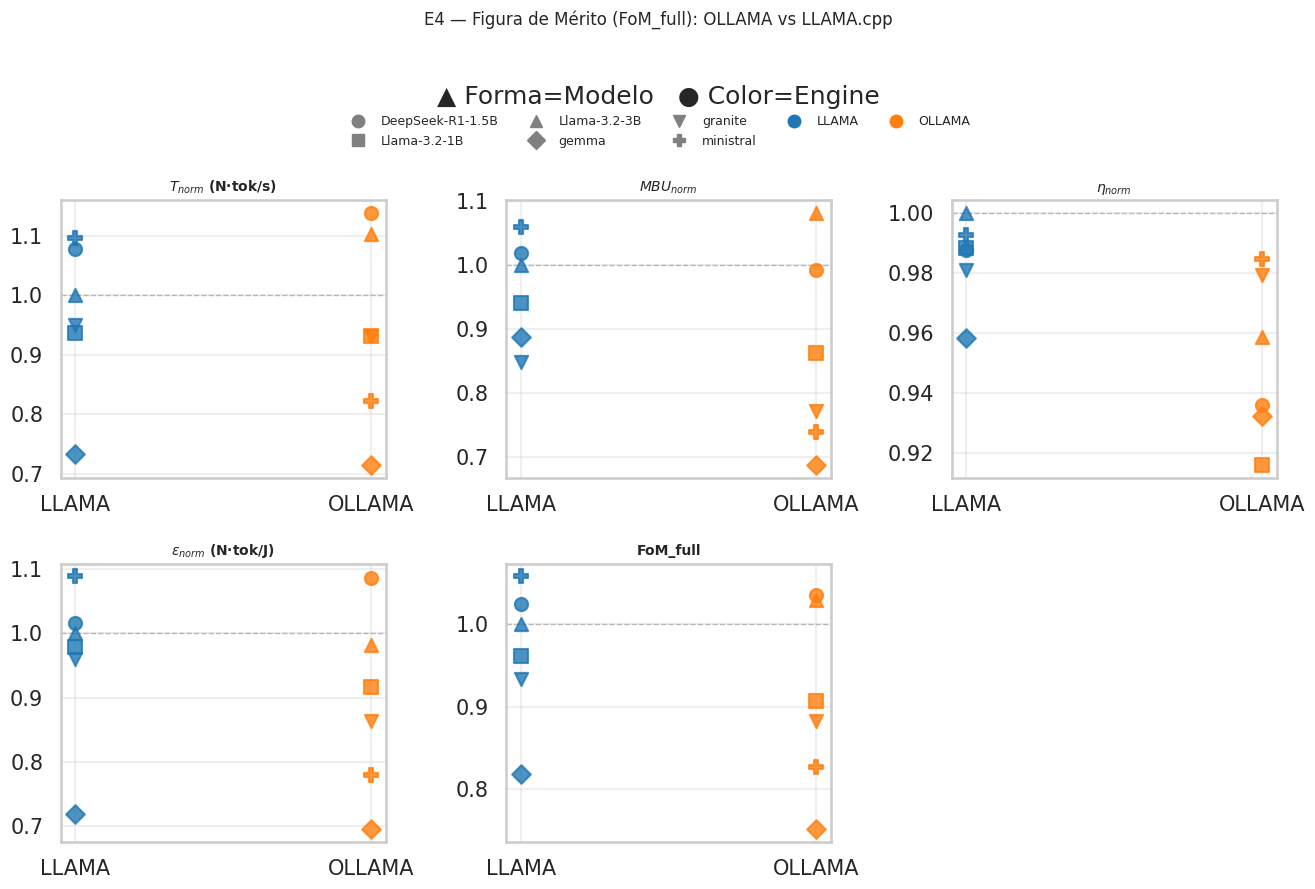

FoM_full por engine y modelo:


,engine,model_base,mbu_corr,tokens_per_s_mean,fom_full
0,OLLAMA,ministral,46.122,3.550,0.826
1,LLAMA,ministral,66.133,4.731,1.058
2,OLLAMA,Llama-3.2-3B,67.563,5.082,1.030
3,LLAMA,Llama-3.2-3B,62.465,4.608,1.000
4,OLLAMA,Llama-3.2-1B,53.886,11.158,0.906
5,LLAMA,Llama-3.2-1B,58.785,11.229,0.961
6,OLLAMA,granite,48.167,4.320,0.883
7,LLAMA,granite,52.965,4.410,0.934
8,OLLAMA,gemma,42.905,5.538,0.751
9,LLAMA,gemma,55.464,5.683,0.818



Criterio de usabilidad (≥3 palabras/s): 10/12 runs usables


,engine,model_base,tokens_per_s_mean,T_hum,usable
0,OLLAMA,ministral,3.550,4.570,False
1,LLAMA,ministral,4.731,4.522,True
2,OLLAMA,Llama-3.2-3B,5.082,4.221,True
3,LLAMA,Llama-3.2-3B,4.608,4.252,True
4,OLLAMA,Llama-3.2-1B,11.158,4.107,True
5,LLAMA,Llama-3.2-1B,11.229,4.416,True
6,OLLAMA,granite,4.320,3.916,True
7,LLAMA,granite,4.410,3.987,True
8,OLLAMA,gemma,5.538,4.445,True
9,LLAMA,gemma,5.683,4.449,True


In [26]:
# ── FoM_full — Figura de Mérito compuesta (E4) ─────────────────────────────
import re as _re
from monitorviz.transforms.fom import compute_fom_full, compute_usability

_FOM_AXES4 = {
    "fom_T_norm":   r"$T_{norm}$ (N·tok/s)",
    "fom_MBU_norm": r"$MBU_{norm}$",
    "fom_eta_norm": r"$\eta_{norm}$",
    "fom_eps_norm": r"$\varepsilon_{norm}$ (N·tok/J)",
    "fom_full":     "FoM_full",
}

try:
    fom_df4 = compute_fom_full(ex)
    fom_df4["model_base"] = (fom_df4["model_label"]
                             .str.replace(r'\s*\([LO]\)\s*', '', regex=True)
                             .str.strip())
    _DEEPSEEK_NORM = {"deepseek:q": "DeepSeek-R1-1.5B", "deepseek-r1:1.5b": "DeepSeek-R1-1.5B"}
    fom_df4["model_base"] = fom_df4["model_base"].map(lambda x: _DEEPSEEK_NORM.get(x, x))
    avail4 = [c for c in _FOM_AXES4 if c in fom_df4.columns and fom_df4[c].notna().any()]

    if avail4:
        _engines4   = sorted(fom_df4["engine"].dropna().unique()) if "engine" in fom_df4.columns else []
        _ENG_COL4   = {"LLAMA": "tab:blue", "OLLAMA": "tab:orange"}
        _mbase4     = sorted(fom_df4["model_base"].dropna().unique())
        _MARKERS4   = ["o","s","^","D","v","P","X"]
        _MOD_MK4    = {m: _MARKERS4[i % len(_MARKERS4)] for i, m in enumerate(_mbase4)}

        _nc4 = 3
        _nr4 = (len(avail4) + _nc4 - 1) // _nc4
        fig4, _ax4 = plt.subplots(_nr4, _nc4, figsize=(_nc4 * 4.5, _nr4 * 4.0))
        _flat4 = _ax4.flatten() if _nr4 > 1 else list(_ax4)

        for ax, col in zip(_flat4, avail4):
            for engine in _engines4:
                for model in _mbase4:
                    _sub = fom_df4[
                        (fom_df4["model_base"]==model) &
                        (fom_df4["engine"]==engine)
                    ].dropna(subset=[col])
                    if _sub.empty: continue
                    ax.scatter(engine, _sub[col].mean(),
                               marker=_MOD_MK4[model],
                               color=_ENG_COL4.get(engine, "tab:gray"),
                               s=90, alpha=0.8, zorder=3)
            ax.axhline(1.0, ls="--", color="gray", alpha=0.5, lw=1)
            ax.set_title(_FOM_AXES4[col], fontsize=10)
            ax.grid(True, alpha=0.3)

        for ax in _flat4[len(avail4):]:
            ax.set_visible(False)

        _mod_h4 = [plt.Line2D([],[],marker=_MOD_MK4[m],color="gray",ls="none",ms=9,label=m) for m in _mbase4]
        _eng_h4 = [plt.Line2D([],[],marker="o",color=_ENG_COL4.get(e,"tab:gray"),ls="none",ms=9,label=e) for e in _engines4]
        fig4.legend(handles=_mod_h4 + _eng_h4,
                    loc="upper center", bbox_to_anchor=(0.5, 1.04),
                    ncol=min(len(_mbase4) + len(_engines4), 5), fontsize=9,
                    title="▲ Forma=Modelo   ● Color=Engine")
        fig4.suptitle("E4 — Figura de Mérito (FoM_full): OLLAMA vs LLAMA.cpp", fontsize=12, y=1.12)
        fig4.tight_layout()
        plt.show()

        _disp4 = [c for c in ["engine", "model_base", "mbu_corr", "tokens_per_s_mean", "fom_full"]
                  if c in fom_df4.columns]
        print("FoM_full por engine y modelo:")
        display(fom_df4[_disp4].round(3))
    if not pm_full.empty:
        fom_df4, _tpw4 = compute_usability(fom_df4, pm_full)
        n_usable4 = int(fom_df4["usable"].sum()) if "usable" in fom_df4.columns else 0
        print(f"\nCriterio de usabilidad (≥3 palabras/s): {n_usable4}/{len(fom_df4)} runs usables")
        _uc4 = [c for c in ["engine", "model_base", "tokens_per_s_mean", "T_hum", "usable"]
                if c in fom_df4.columns]
        if _uc4:
            display(fom_df4[_uc4].round(3))
except Exception as e:
    print(f"Error en FoM: {e}")


## Conclusiones y discusión

### Confirmación/refutación de hipótesis
> TODO

### Hallazgos principales
> TODO

### Limitaciones
> TODO